# Documentation Quality EDA

Analysis of the two-track documentation quality scoring system for 10,698 open-source hardware projects.

- **Track 1** (metadata-based): Completeness, Coverage, Depth, Open-o-Meter -- all 10,698 projects
- **Track 2** (LLM-based): Gemini 2.5 Flash Lite evaluation across 12 dimensions -- 7,024 GitHub projects

This notebook validates score distributions, cross-validates Track 1 metadata proxies against
Track 2 ground truth, and identifies systematic documentation gaps by source.

## 0. Setup

In [1]:
import sqlite3
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns

# ---- Paths ----
DB_PATH = Path("../data/osh_datasets.db")


def get_conn() -> sqlite3.Connection:
    """Read-only connection with WAL mode."""
    conn = sqlite3.connect(f"file:{DB_PATH}?mode=ro", uri=True)
    conn.execute("PRAGMA journal_mode=WAL")
    return conn


def sql(query: str) -> pl.DataFrame:
    """Execute SQL and return a polars DataFrame."""
    conn = get_conn()
    cursor = conn.execute(query)
    cols = [desc[0] for desc in cursor.description]
    rows = cursor.fetchall()
    conn.close()
    return pl.DataFrame({c: [r[i] for r in rows] for i, c in enumerate(cols)})


# ---- Plot style ----
sns.set_theme(style="whitegrid", font_scale=1.1)
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 120,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

# ---- Polars display ----
pl.Config.set_tbl_rows(20)
pl.Config.set_fmt_str_lengths(60)

print(f"Database: {DB_PATH} ({DB_PATH.stat().st_size / 1e6:.1f} MB)")

Database: ../data/osh_datasets.db (593.8 MB)


## 1. Dataset Overview

In [2]:
# Table row counts
tables = [
    "projects", "licenses", "tags", "contributors", "metrics",
    "bom_components", "publications", "cross_references",
    "repo_metrics", "bom_file_paths", "component_prices",
    "doc_quality_scores", "readme_contents", "repo_file_trees",
    "llm_evaluations",
]
conn = get_conn()
counts = {
    t: conn.execute(f"SELECT COUNT(*) FROM {t}").fetchone()[0]
    for t in tables
}
conn.close()
print(pl.DataFrame({"table": list(counts.keys()), "rows": list(counts.values())}))

shape: (15, 2)
┌────────────────────┬─────────┐
│ table              ┆ rows    │
│ ---                ┆ ---     │
│ str                ┆ i64     │
╞════════════════════╪═════════╡
│ projects           ┆ 10698   │
│ licenses           ┆ 13160   │
│ tags               ┆ 60541   │
│ contributors       ┆ 13916   │
│ metrics            ┆ 21031   │
│ bom_components     ┆ 88202   │
│ publications       ┆ 793     │
│ cross_references   ┆ 304     │
│ repo_metrics       ┆ 7650    │
│ bom_file_paths     ┆ 2792    │
│ component_prices   ┆ 60071   │
│ doc_quality_scores ┆ 10698   │
│ readme_contents    ┆ 7831    │
│ repo_file_trees    ┆ 2880048 │
│ llm_evaluations    ┆ 7024    │
└────────────────────┴─────────┘


shape: (10, 2)
┌────────────┬──────┐
│ source     ┆ n    │
│ ---        ┆ ---  │
│ str        ┆ i64  │
╞════════════╪══════╡
│ hackaday   ┆ 5697 │
│ oshwa      ┆ 3052 │
│ ohx        ┆ 567  │
│ hardwareio ┆ 515  │
│ ohr        ┆ 247  │
│ osf        ┆ 208  │
│ kitspace   ┆ 186  │
│ mendeley   ┆ 178  │
│ joh        ┆ 29   │
│ plos       ┆ 19   │
└────────────┴──────┘


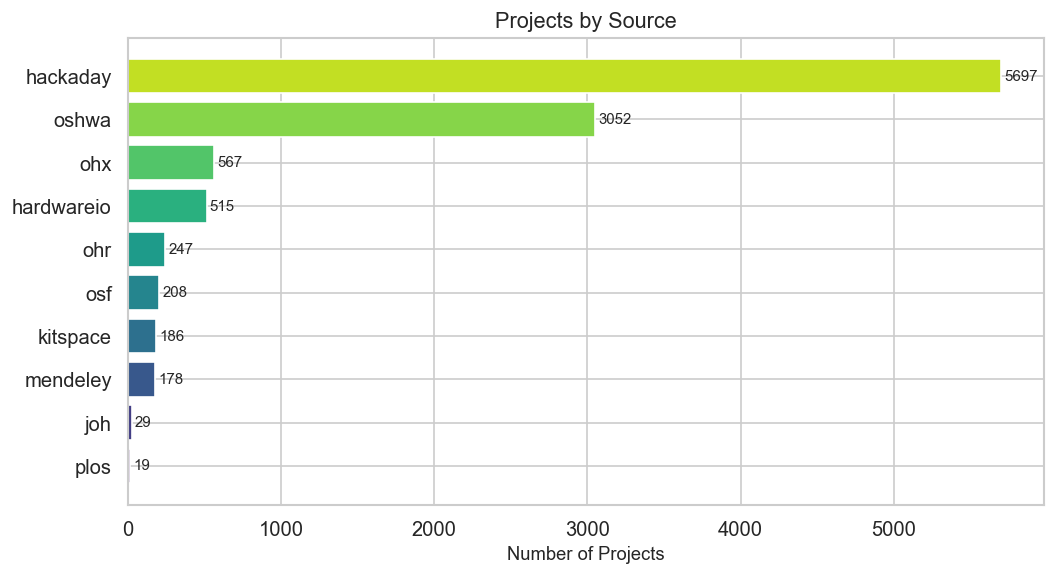

In [3]:
# Projects by source
df_sources = sql(
    "SELECT source, COUNT(*) AS n FROM projects GROUP BY source ORDER BY n DESC"
)
print(df_sources)

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(
    df_sources["source"].to_list()[::-1],
    df_sources["n"].to_list()[::-1],
    color=sns.color_palette("viridis", len(df_sources)),
)
ax.set_xlabel("Number of Projects")
ax.set_title("Projects by Source")
for i, v in enumerate(df_sources["n"].to_list()[::-1]):
    ax.text(v + 20, i, str(v), va="center", fontsize=9)
plt.tight_layout()
plt.show()

In [4]:
# Track coverage and overlap
df_coverage = sql("""
SELECT
    (SELECT COUNT(*) FROM doc_quality_scores) AS track1_count,
    (SELECT COUNT(*) FROM llm_evaluations) AS track2_count,
    (SELECT COUNT(*) FROM doc_quality_scores d
     JOIN llm_evaluations l ON d.project_id = l.project_id
    ) AS overlap_count,
    (SELECT COUNT(*) FROM projects
     WHERE repo_url IS NOT NULL AND repo_url != ''
    ) AS has_repo_url,
    (SELECT COUNT(*) FROM repo_metrics) AS has_repo_metrics,
    (SELECT MIN(created_at) FROM projects
     WHERE created_at IS NOT NULL AND created_at != ''
    ) AS earliest_project,
    (SELECT MAX(created_at) FROM projects
     WHERE created_at IS NOT NULL AND created_at != ''
    ) AS latest_project
""")
print(df_coverage)

shape: (1, 7)
┌──────────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────────┐
│ track1_count ┆ track2_coun ┆ overlap_cou ┆ has_repo_ur ┆ has_repo_me ┆ earliest_pr ┆ latest_proj │
│ ---          ┆ t           ┆ nt          ┆ l           ┆ trics       ┆ oject       ┆ ect         │
│ i64          ┆ ---         ┆ ---         ┆ ---         ┆ ---         ┆ ---         ┆ ---         │
│              ┆ i64         ┆ i64         ┆ i64         ┆ i64         ┆ str         ┆ str         │
╞══════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╪═════════════╡
│ 10698        ┆ 7024        ┆ 7024        ┆ 8824        ┆ 7650        ┆ 2011-04-18T ┆ NULL        │
│              ┆             ┆             ┆             ┆             ┆ 17:20:01Z   ┆             │
└──────────────┴─────────────┴─────────────┴─────────────┴─────────────┴─────────────┴─────────────┘


## 2. Track 1 Score Distributions

In [5]:
# Load Track 1 scores with source labels
df_t1 = sql("""
SELECT
    d.project_id,
    p.source,
    d.completeness_score,
    d.coverage_score,
    d.depth_score,
    d.open_o_meter_score
FROM doc_quality_scores d
JOIN projects p ON d.project_id = p.id
""")

# Summary statistics
score_cols = [
    "completeness_score", "coverage_score",
    "depth_score", "open_o_meter_score",
]
print(df_t1.select(score_cols).describe())

shape: (9, 5)
┌────────────┬────────────────────┬────────────────┬─────────────┬────────────────────┐
│ statistic  ┆ completeness_score ┆ coverage_score ┆ depth_score ┆ open_o_meter_score │
│ ---        ┆ ---                ┆ ---            ┆ ---         ┆ ---                │
│ str        ┆ f64                ┆ f64            ┆ f64         ┆ f64                │
╞════════════╪════════════════════╪════════════════╪═════════════╪════════════════════╡
│ count      ┆ 10698.0            ┆ 10698.0        ┆ 10698.0     ┆ 10698.0            │
│ null_count ┆ 0.0                ┆ 0.0            ┆ 0.0         ┆ 0.0                │
│ mean       ┆ 63.35558           ┆ 56.284072      ┆ 53.610581   ┆ 5.028043           │
│ std        ┆ 21.21641           ┆ 16.923271      ┆ 25.748366   ┆ 2.13575            │
│ min        ┆ 0.0                ┆ 17.0           ┆ 0.0         ┆ 0.0                │
│ 25%        ┆ 45.0               ┆ 50.0           ┆ 34.0        ┆ 3.0                │
│ 50%        ┆ 70.

In [6]:
# Sanity checks
for col, lo, hi in [
    ("completeness_score", 0, 100),
    ("coverage_score", 0, 100),
    ("depth_score", 0, 100),
    ("open_o_meter_score", 0, 8),
]:
    vals = df_t1[col]
    n_null = vals.null_count()
    n_below = (vals < lo).sum()
    n_above = (vals > hi).sum()
    n_at_floor = (vals == lo).sum()
    n_at_ceil = (vals == hi).sum()
    print(
        f"{col:25s}  nulls={n_null}  below={n_below}  "
        f"above={n_above}  floor={n_at_floor}  ceiling={n_at_ceil}"
    )

completeness_score         nulls=0  below=0  above=0  floor=52  ceiling=217
coverage_score             nulls=0  below=0  above=0  floor=0  ceiling=0
depth_score                nulls=0  below=0  above=0  floor=97  ceiling=1106
open_o_meter_score         nulls=0  below=0  above=0  floor=264  ceiling=891


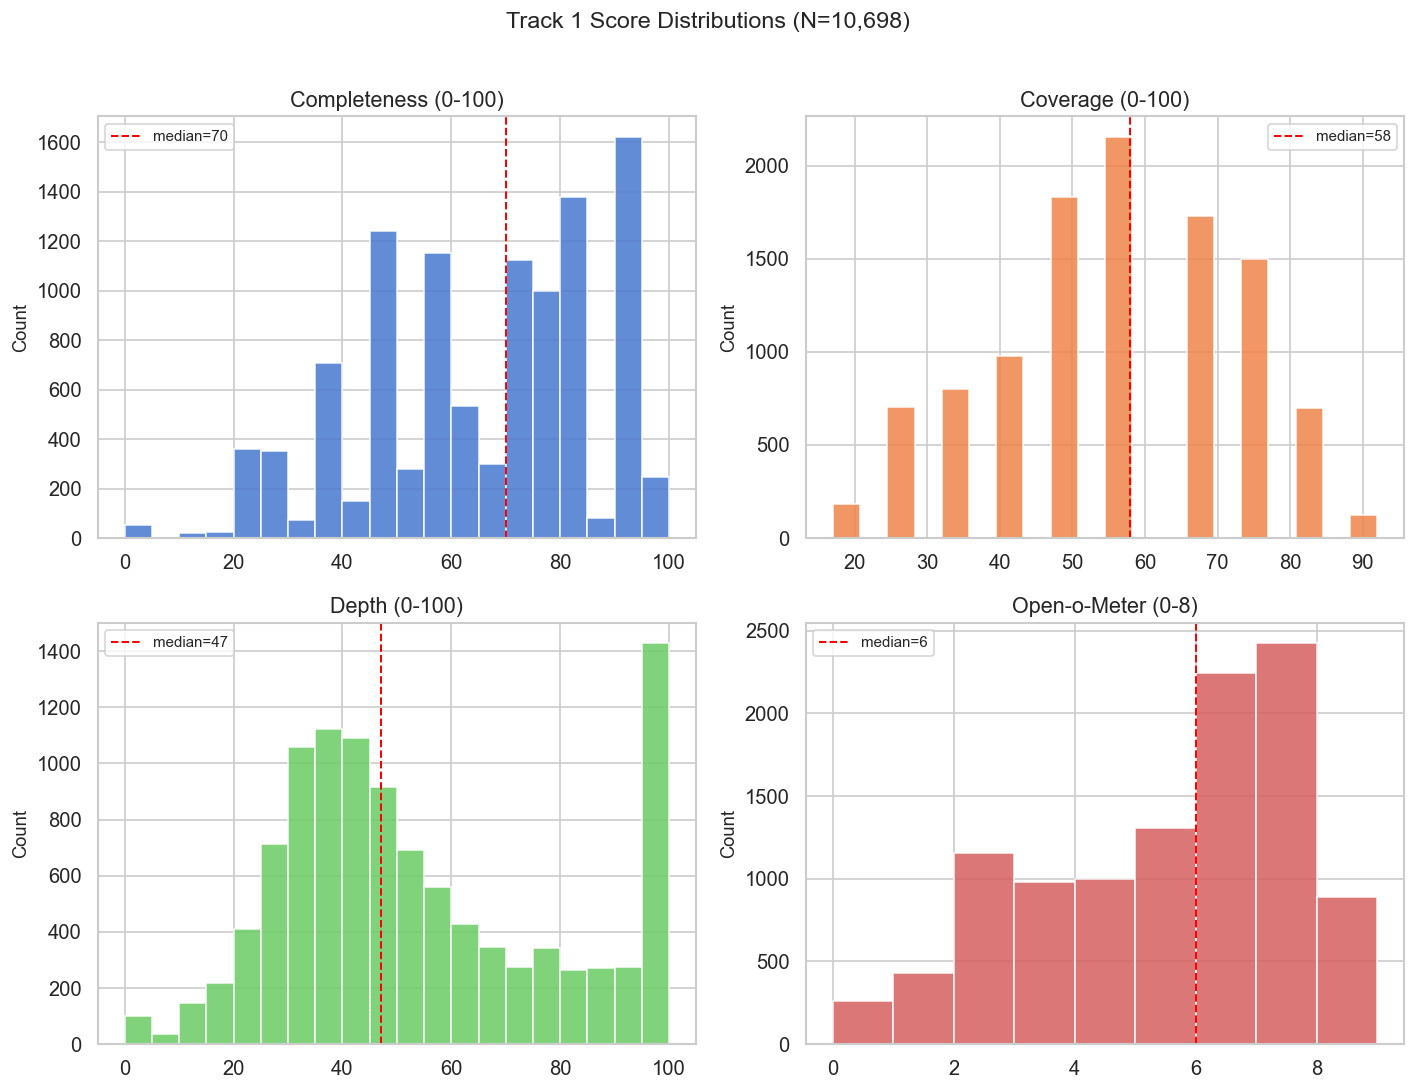

In [7]:
# 2x2 histogram grid
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
titles = ["Completeness (0-100)", "Coverage (0-100)",
          "Depth (0-100)", "Open-o-Meter (0-8)"]
colors = sns.color_palette("muted", 4)

for ax, col, title, color in zip(axes.flat, score_cols, titles, colors):
    data = df_t1[col].to_list()
    bins = 20 if "open_o_meter" not in col else list(range(10))
    ax.hist(data, bins=bins, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(np.median(data), color="red", linestyle="--",
               linewidth=1.2, label=f"median={np.median(data):.0f}")
    ax.set_title(title)
    ax.set_ylabel("Count")
    ax.legend(fontsize=9)

fig.suptitle("Track 1 Score Distributions (N={:,})".format(len(df_t1)),
             fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

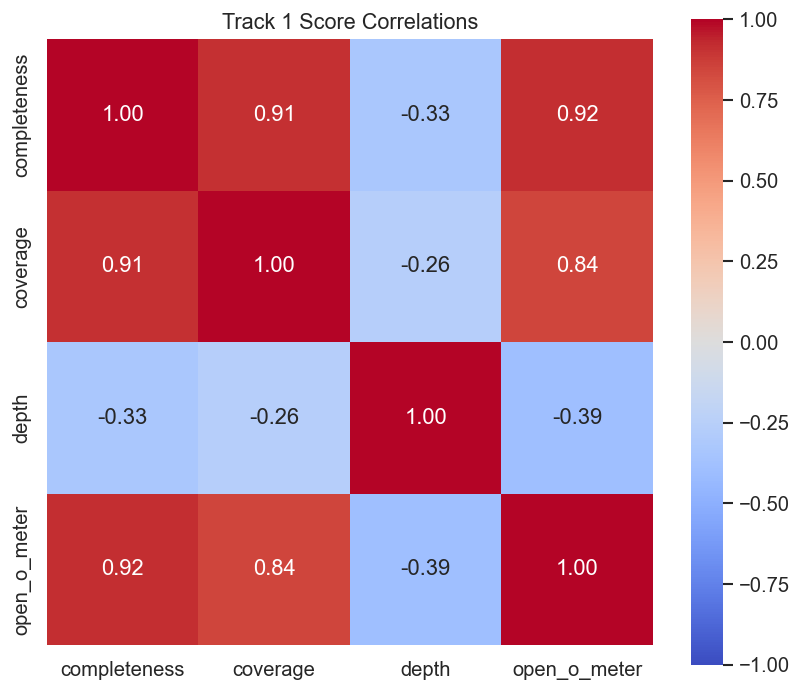

In [8]:
# Correlation matrix
corr = df_t1.select(score_cols).to_pandas().corr()
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(
    corr, annot=True, fmt=".2f", cmap="coolwarm", center=0,
    vmin=-1, vmax=1, square=True,
    xticklabels=[c.replace("_score", "") for c in score_cols],
    yticklabels=[c.replace("_score", "") for c in score_cols],
    ax=ax,
)
ax.set_title("Track 1 Score Correlations")
plt.tight_layout()
plt.show()

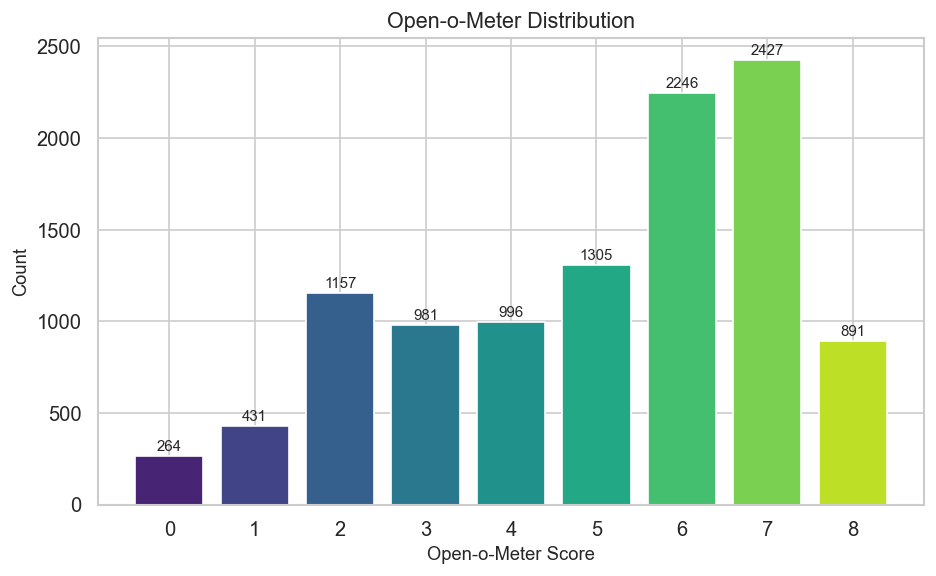

In [9]:
# Open-o-Meter integer distribution
oom_counts = (
    df_t1.group_by("open_o_meter_score")
    .agg(pl.len().alias("n"))
    .sort("open_o_meter_score")
)
fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(
    oom_counts["open_o_meter_score"].to_list(),
    oom_counts["n"].to_list(),
    color=sns.color_palette("viridis", len(oom_counts)),
    edgecolor="white",
)
for i, (score, n) in enumerate(
    zip(oom_counts["open_o_meter_score"].to_list(),
        oom_counts["n"].to_list())
):
    ax.text(score, n + 30, str(n), ha="center", fontsize=9)
ax.set_xlabel("Open-o-Meter Score")
ax.set_ylabel("Count")
ax.set_title("Open-o-Meter Distribution")
ax.set_xticks(range(9))
plt.tight_layout()
plt.show()

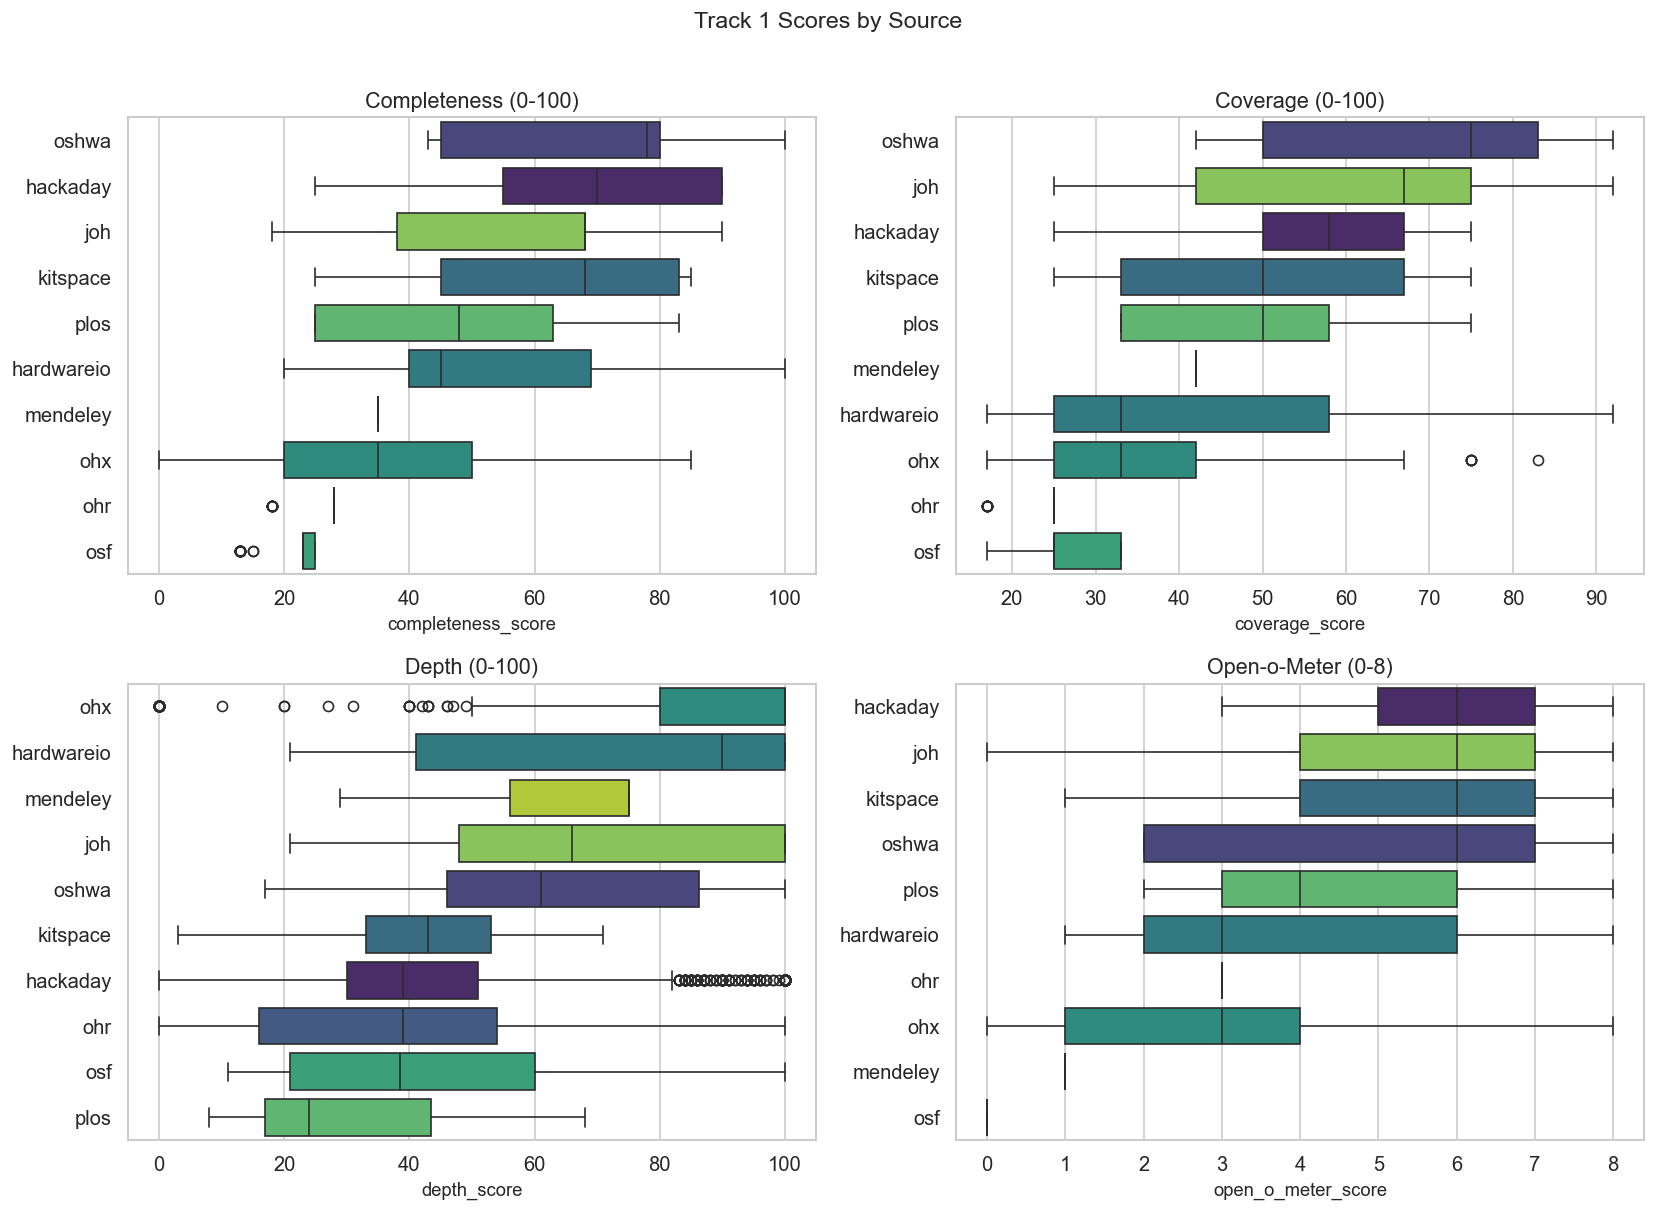

In [10]:
# Score distributions by source (box plots)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
df_pd = df_t1.to_pandas()

for ax, col, title in zip(axes.flat, score_cols, titles):
    source_order = (
        df_pd.groupby("source")[col]
        .median()
        .sort_values(ascending=False)
        .index.tolist()
    )
    sns.boxplot(
        data=df_pd, x=col, y="source", order=source_order,
        hue="source", palette="viridis", legend=False, ax=ax,
    )
    ax.set_title(title)
    ax.set_ylabel("")

fig.suptitle("Track 1 Scores by Source", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

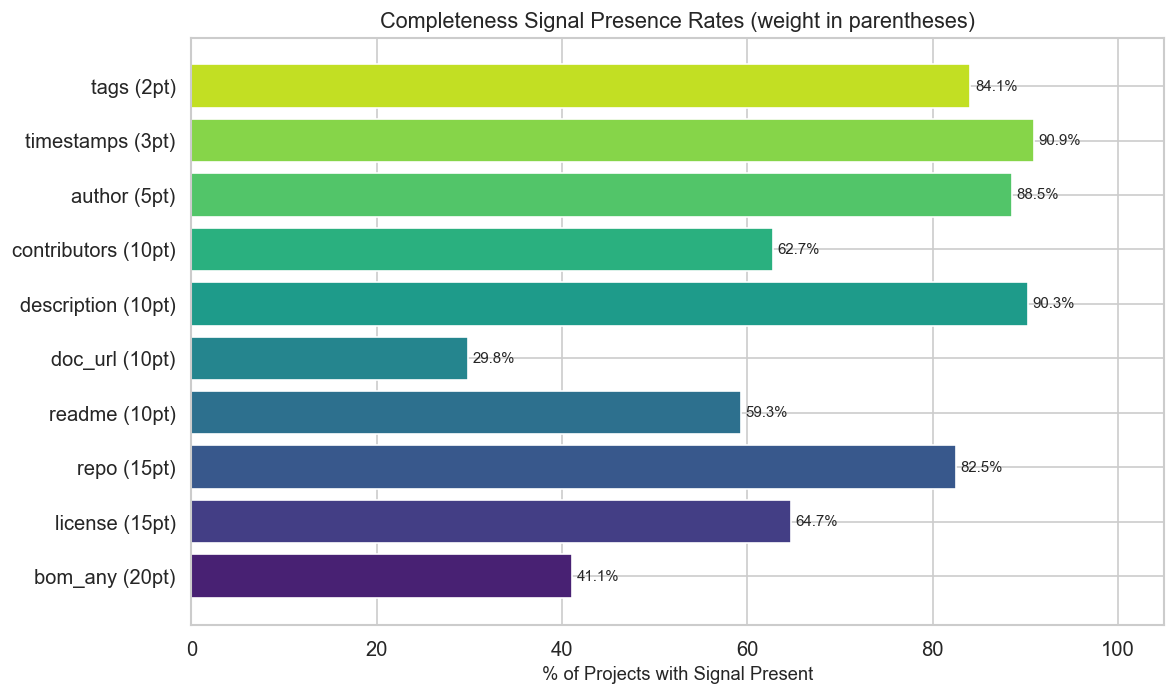

In [11]:
# Completeness signal decomposition
# Re-derive per-signal flags using the same SQL logic from doc_quality.py
df_signals = sql("""
SELECT
    p.source,
    (COALESCE(rm.has_bom, 0) = 1
     OR EXISTS (SELECT 1 FROM bom_components bc WHERE bc.project_id = p.id)
     OR EXISTS (SELECT 1 FROM bom_file_paths bf WHERE bf.project_id = p.id)
    ) AS has_bom_any,
    EXISTS (SELECT 1 FROM licenses li WHERE li.project_id = p.id)
        AS has_license,
    (p.repo_url IS NOT NULL AND p.repo_url != '') AS has_repo,
    COALESCE(rm.has_readme, 0) AS has_readme,
    (p.documentation_url IS NOT NULL AND p.documentation_url != '')
        AS has_doc_url,
    (p.description IS NOT NULL AND p.description != '')
        AS has_description,
    EXISTS (SELECT 1 FROM contributors c WHERE c.project_id = p.id)
        AS has_contributors,
    (p.author IS NOT NULL AND p.author != '') AS has_author,
    (p.created_at IS NOT NULL AND p.created_at != '')
        AS has_timestamps,
    EXISTS (SELECT 1 FROM tags t WHERE t.project_id = p.id)
        AS has_tags
FROM projects p
LEFT JOIN (
    SELECT project_id,
           MAX(has_bom) AS has_bom,
           MAX(has_readme) AS has_readme
    FROM repo_metrics
    GROUP BY project_id
) rm ON p.id = rm.project_id
""")

signal_names = [
    "has_bom_any", "has_license", "has_repo", "has_readme",
    "has_doc_url", "has_description", "has_contributors",
    "has_author", "has_timestamps", "has_tags",
]
weights = [20, 15, 15, 10, 10, 10, 10, 5, 3, 2]

# Overall signal presence rates
rates = [
    df_signals[s].cast(pl.Int32).sum() / len(df_signals) * 100
    for s in signal_names
]

fig, ax = plt.subplots(figsize=(10, 6))
labels = [f"{s.replace('has_', '')} ({w}pt)" for s, w in zip(signal_names, weights)]
bar_colors = sns.color_palette("viridis", len(signal_names))
y_pos = range(len(signal_names))
ax.barh(y_pos, rates, color=bar_colors, edgecolor="white")
ax.set_yticks(y_pos)
ax.set_yticklabels(labels)
ax.set_xlabel("% of Projects with Signal Present")
ax.set_title("Completeness Signal Presence Rates (weight in parentheses)")
for i, r in enumerate(rates):
    ax.text(r + 0.5, i, f"{r:.1f}%", va="center", fontsize=9)
ax.set_xlim(0, 105)
plt.tight_layout()
plt.show()

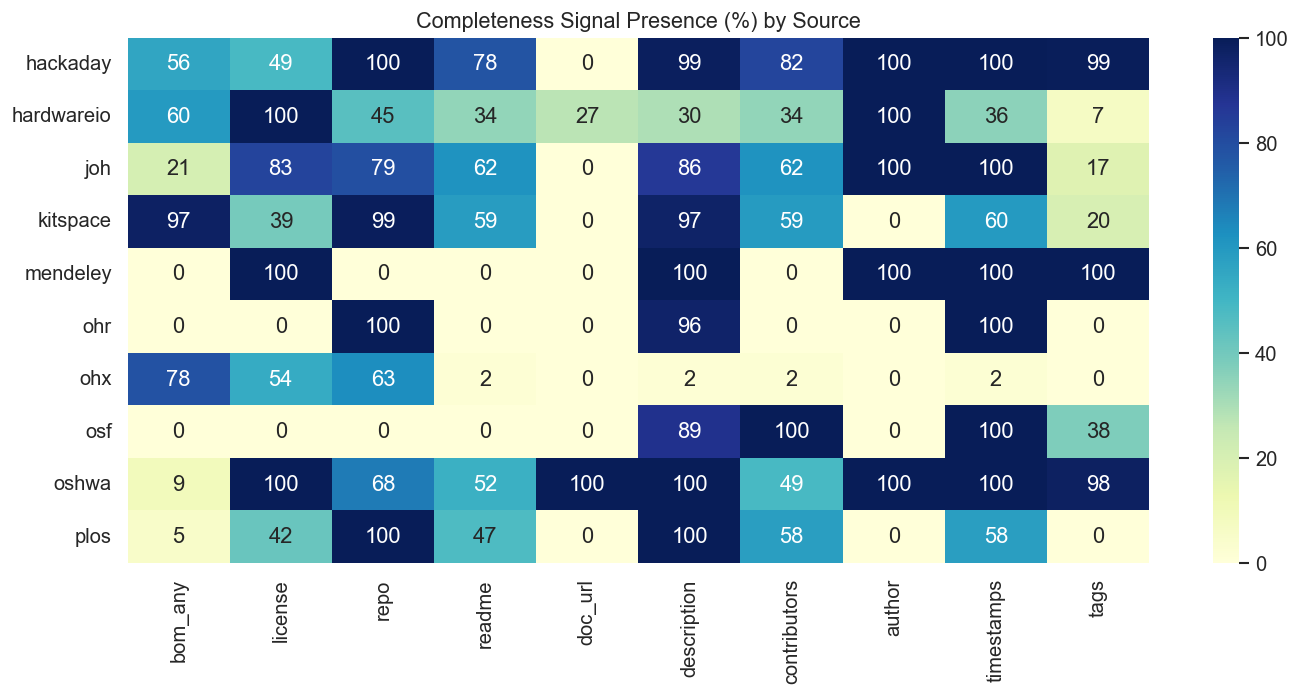

In [12]:
# Signal presence rates by source (heatmap)
signal_by_source = (
    df_signals.group_by("source")
    .agg([
        (pl.col(s).cast(pl.Int32).sum() / pl.len() * 100).alias(s)
        for s in signal_names
    ])
    .sort("source")
)

matrix = signal_by_source.select(signal_names).to_pandas()
matrix.index = signal_by_source["source"].to_list()

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    matrix, annot=True, fmt=".0f", cmap="YlGnBu",
    xticklabels=[s.replace("has_", "") for s in signal_names],
    ax=ax, vmin=0, vmax=100,
)
ax.set_title("Completeness Signal Presence (%) by Source")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

## 3. Track 2 LLM Evaluation Distributions

In [13]:
# Load Track 2 data
df_t2 = sql("""
SELECT
    l.project_id,
    p.source,
    l.project_type,
    l.structure_quality,
    l.license_present,
    l.license_type,
    l.contributing_present,
    l.contributing_level,
    l.bom_present,
    l.bom_completeness,
    l.bom_component_count,
    l.assembly_present,
    l.assembly_detail,
    l.assembly_step_count,
    l.hw_design_present,
    l.hw_editable_source,
    l.mech_design_present,
    l.mech_editable_source,
    l.sw_fw_present,
    l.sw_fw_type,
    l.sw_fw_doc_level,
    l.testing_present,
    l.testing_detail,
    l.cost_mentioned,
    l.suppliers_referenced,
    l.part_numbers_present,
    l.maturity_stage,
    l.hw_license_name,
    l.sw_license_name,
    l.doc_license_name
FROM llm_evaluations l
JOIN projects p ON l.project_id = p.id
""")
print(f"Track 2 projects: {len(df_t2):,}")

Track 2 projects: 7,024


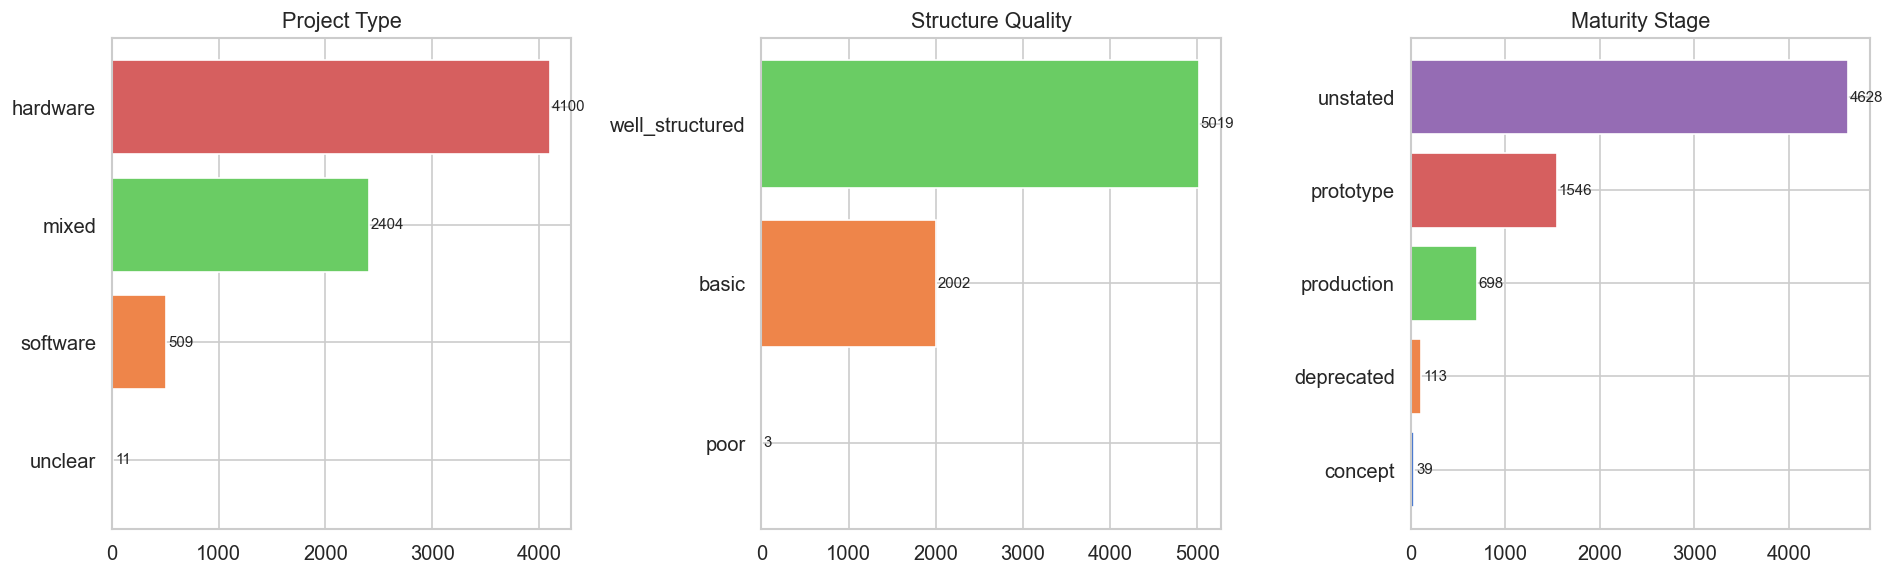

In [14]:
# Categorical distributions: project_type, structure_quality, maturity_stage
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, title in zip(
    axes,
    ["project_type", "structure_quality", "maturity_stage"],
    ["Project Type", "Structure Quality", "Maturity Stage"],
):
    counts = (
        df_t2.group_by(col)
        .agg(pl.len().alias("n"))
        .sort("n", descending=True)
    )
    vals = counts[col].to_list()
    ns = counts["n"].to_list()
    ax.barh(vals[::-1], ns[::-1],
            color=sns.color_palette("muted", len(vals)))
    ax.set_title(title)
    for i, n in enumerate(ns[::-1]):
        ax.text(n + 20, i, str(n), va="center", fontsize=9)

plt.tight_layout()
plt.show()

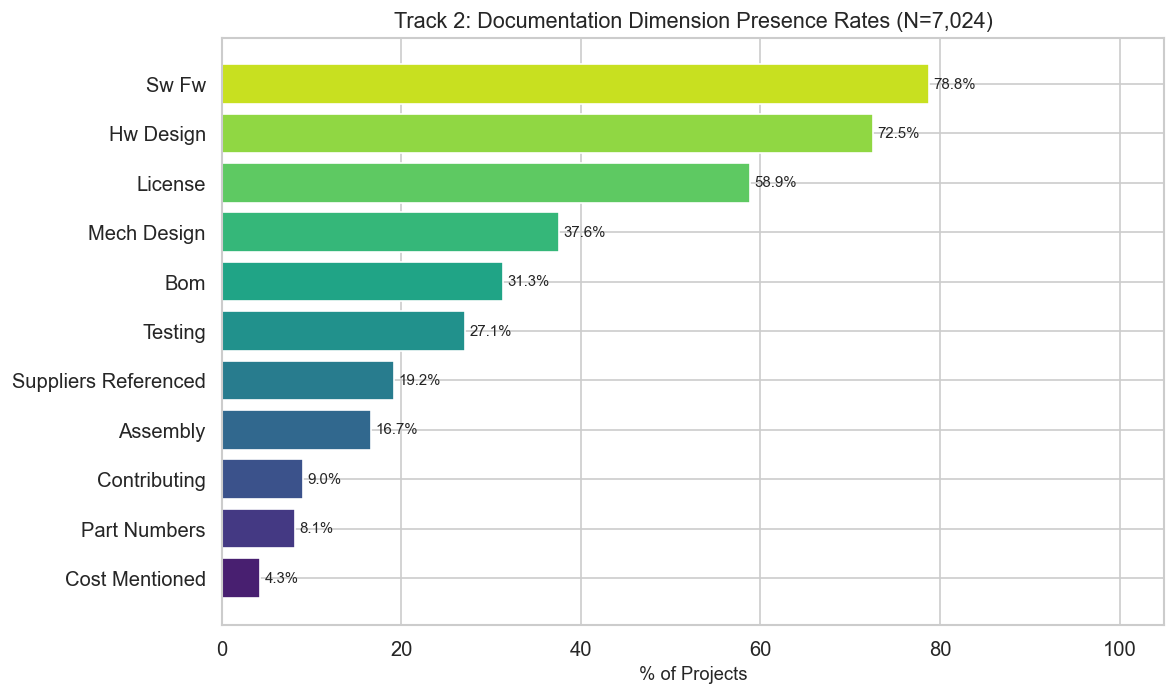

In [15]:
# Documentation presence rates (binary flags)
binary_cols = [
    "license_present", "bom_present", "assembly_present",
    "hw_design_present", "mech_design_present",
    "sw_fw_present", "testing_present", "contributing_present",
    "cost_mentioned", "suppliers_referenced", "part_numbers_present",
]
presence_rates = [
    (col.replace("_present", "").replace("_", " ").title(),
     df_t2[col].cast(pl.Int32).sum() / len(df_t2) * 100)
    for col in binary_cols
]
presence_rates.sort(key=lambda x: x[1], reverse=True)

fig, ax = plt.subplots(figsize=(10, 6))
labels, rates = zip(*presence_rates)
y_pos = range(len(labels))
ax.barh(
    [l for l in labels][::-1],
    list(rates)[::-1],
    color=sns.color_palette("viridis", len(labels)),
    edgecolor="white",
)
for i, r in enumerate(list(rates)[::-1]):
    ax.text(r + 0.5, i, f"{r:.1f}%", va="center", fontsize=9)
ax.set_xlabel("% of Projects")
ax.set_title("Track 2: Documentation Dimension Presence Rates (N={:,})".format(len(df_t2)))
ax.set_xlim(0, 105)
plt.tight_layout()
plt.show()

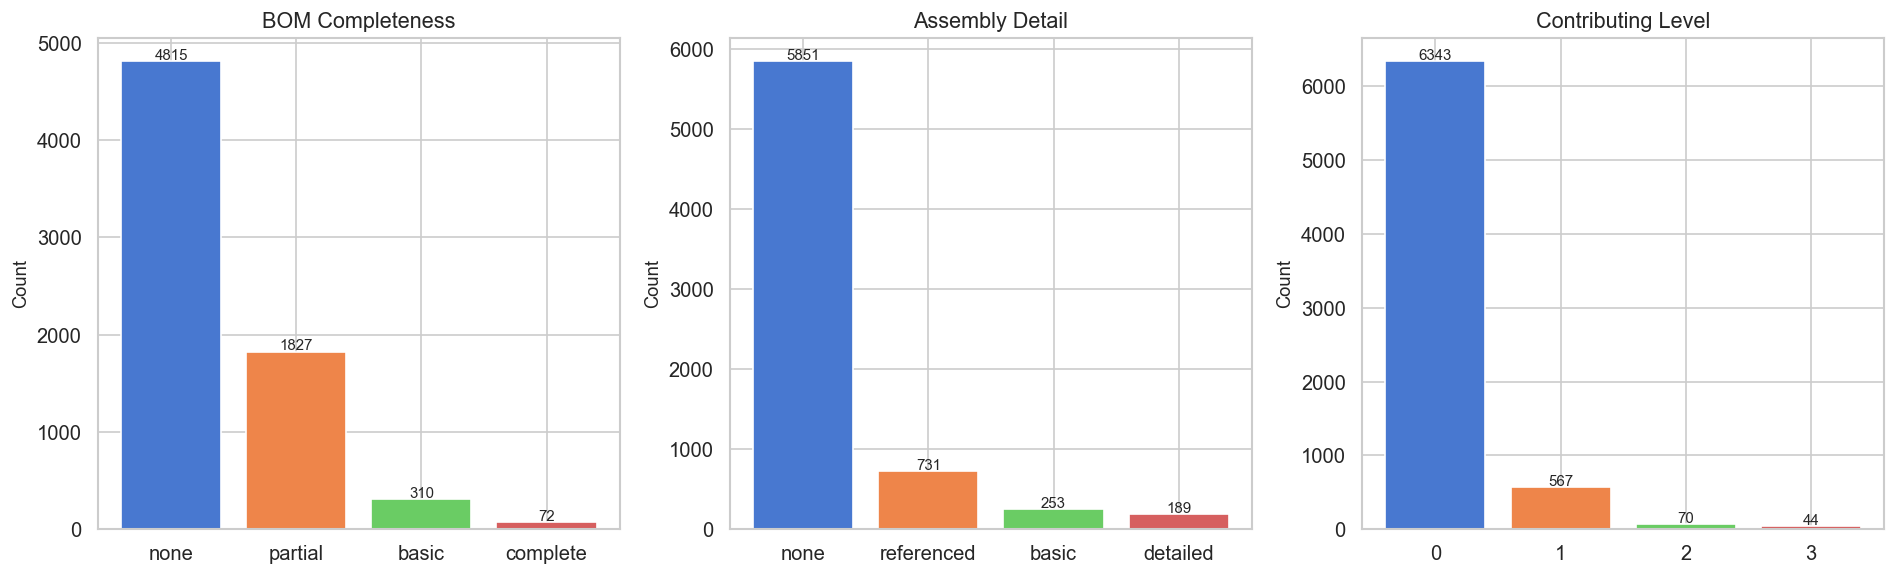

In [16]:
# BOM completeness, assembly detail, contributing level distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, col, title in zip(
    axes,
    ["bom_completeness", "assembly_detail", "contributing_level"],
    ["BOM Completeness", "Assembly Detail", "Contributing Level"],
):
    sub = df_t2.filter(pl.col(col).is_not_null())
    counts = (
        sub.group_by(col)
        .agg(pl.len().alias("n"))
        .sort("n", descending=True)
    )
    vals = [str(v) for v in counts[col].to_list()]
    ns = counts["n"].to_list()
    ax.bar(vals, ns, color=sns.color_palette("muted", len(vals)),
           edgecolor="white")
    ax.set_title(title)
    ax.set_ylabel("Count")
    for i, n in enumerate(ns):
        ax.text(i, n + 20, str(n), ha="center", fontsize=9)

plt.tight_layout()
plt.show()

In [17]:
# License type and domain-specific license analysis
license_type_counts = (
    df_t2.group_by("license_type")
    .agg(pl.len().alias("n"))
    .sort("n", descending=True)
)
print("License type distribution:")
print(license_type_counts)

# Domain-specific: how many have distinct hw/sw/doc licenses?
n_hw_lic = df_t2.filter(
    pl.col("hw_license_name").is_not_null()
    & (pl.col("hw_license_name") != "")
).height
n_sw_lic = df_t2.filter(
    pl.col("sw_license_name").is_not_null()
    & (pl.col("sw_license_name") != "")
).height
n_doc_lic = df_t2.filter(
    pl.col("doc_license_name").is_not_null()
    & (pl.col("doc_license_name") != "")
).height
print(f"\nProjects with HW license name: {n_hw_lic}")
print(f"Projects with SW license name: {n_sw_lic}")
print(f"Projects with Doc license name: {n_doc_lic}")

License type distribution:
shape: (6, 2)
┌────────────────┬──────┐
│ license_type   ┆ n    │
│ ---            ┆ ---  │
│ str            ┆ u32  │
╞════════════════╪══════╡
│ none           ┆ 2812 │
│ explicit       ┆ 1991 │
│ file reference ┆ 1305 │
│ referenced     ┆ 627  │
│ file_reference ┆ 175  │
│ implied        ┆ 114  │
└────────────────┴──────┘

Projects with HW license name: 1006
Projects with SW license name: 1095
Projects with Doc license name: 1010


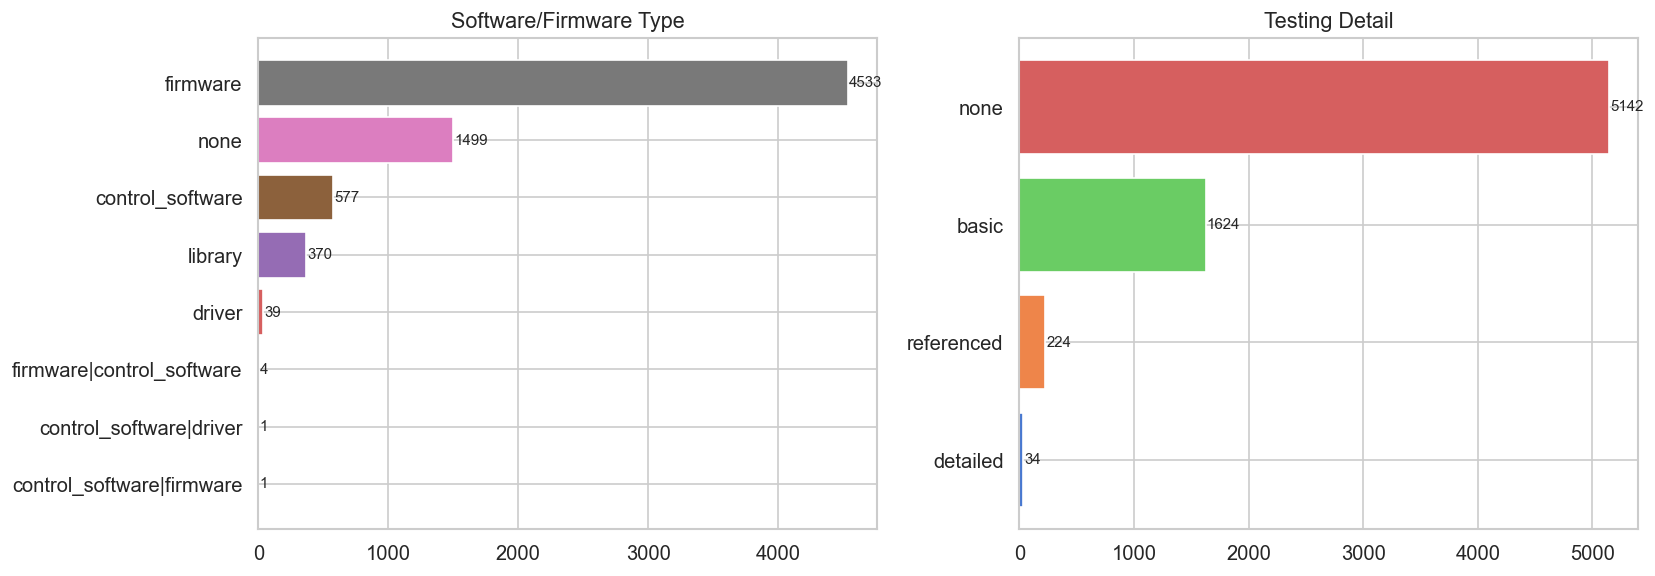

In [18]:
# Software/firmware type and testing detail
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in zip(
    axes,
    ["sw_fw_type", "testing_detail"],
    ["Software/Firmware Type", "Testing Detail"],
):
    sub = df_t2.filter(pl.col(col).is_not_null())
    counts = (
        sub.group_by(col)
        .agg(pl.len().alias("n"))
        .sort("n", descending=True)
    )
    vals = counts[col].to_list()
    ns = counts["n"].to_list()
    ax.barh(vals[::-1], ns[::-1],
            color=sns.color_palette("muted", len(vals)))
    ax.set_title(title)
    for i, n in enumerate(ns[::-1]):
        ax.text(n + 10, i, str(n), va="center", fontsize=9)

plt.tight_layout()
plt.show()

## 4. Cross-Validation: Track 1 Proxies vs Track 2 Ground Truth

The core analytical contribution: quantifying false-positive rates of metadata-based proxies
by comparing them against LLM evaluation ground truth.

In [19]:
# Load joined data for cross-validation
df_xval = sql("""
SELECT
    p.id AS project_id,
    p.source,
    p.repo_url,

    -- Track 1 proxy signals
    COALESCE(rm.has_readme, 0) AS proxy_has_readme,
    (p.repo_url IS NOT NULL AND p.repo_url != '') AS proxy_has_repo,
    (COALESCE(rm.has_bom, 0) = 1
     OR EXISTS (SELECT 1 FROM bom_components bc WHERE bc.project_id = p.id)
     OR EXISTS (SELECT 1 FROM bom_file_paths bf WHERE bf.project_id = p.id)
    ) AS proxy_has_bom,
    EXISTS (SELECT 1 FROM licenses li WHERE li.project_id = p.id)
        AS proxy_has_license,
    (rm.community_health IS NOT NULL AND rm.community_health >= 25)
        AS proxy_has_contrib_guide,

    -- Track 1 scores
    d.completeness_score,
    d.open_o_meter_score,

    -- Track 2 ground truth
    COALESCE(l.assembly_present, 0) AS gt_assembly,
    l.assembly_detail AS gt_assembly_detail,
    COALESCE(l.hw_design_present, 0) AS gt_hw_design,
    COALESCE(l.mech_design_present, 0) AS gt_mech_design,
    COALESCE(l.bom_present, 0) AS gt_bom,
    l.bom_completeness AS gt_bom_completeness,
    COALESCE(l.license_present, 0) AS gt_license,
    l.license_type AS gt_license_type,
    COALESCE(l.contributing_present, 0) AS gt_contributing,
    l.contributing_level AS gt_contributing_level,
    l.project_type,
    COALESCE(l.hw_editable_source, 0) AS gt_hw_editable,
    COALESCE(l.sw_fw_present, 0) AS gt_sw_fw
FROM llm_evaluations l
JOIN projects p ON l.project_id = p.id
JOIN doc_quality_scores d ON d.project_id = p.id
LEFT JOIN (
    SELECT project_id,
           MAX(has_bom) AS has_bom,
           MAX(has_readme) AS has_readme,
           MAX(community_health) AS community_health
    FROM repo_metrics
    GROUP BY project_id
) rm ON p.id = rm.project_id
""")
print(f"Cross-validation set: {len(df_xval):,} projects")

Cross-validation set: 7,024 projects


In [20]:
def confusion_matrix(
    df: pl.DataFrame, proxy_col: str, gt_col: str,
) -> dict[str, int]:
    """Compute confusion matrix counts.

    Args:
        df: DataFrame with proxy and ground truth columns.
        proxy_col: Column name for the metadata proxy (0/1).
        gt_col: Column name for the LLM ground truth (0/1).

    Returns:
        Dict with tp, fp, tn, fn counts.
    """
    proxy = df[proxy_col].cast(pl.Int32)
    gt = df[gt_col].cast(pl.Int32)
    tp = ((proxy == 1) & (gt == 1)).sum()
    fp = ((proxy == 1) & (gt == 0)).sum()
    tn = ((proxy == 0) & (gt == 0)).sum()
    fn = ((proxy == 0) & (gt == 1)).sum()
    return {"tp": tp, "fp": fp, "tn": tn, "fn": fn}


def print_confusion(
    label: str, cm: dict[str, int],
) -> tuple[float, float]:
    """Print confusion matrix and return FPR, FNR.

    Args:
        label: Description of the comparison.
        cm: Dict with tp, fp, tn, fn counts.

    Returns:
        Tuple of (false_positive_rate, false_negative_rate).
    """
    total = cm["tp"] + cm["fp"] + cm["tn"] + cm["fn"]
    fpr = cm["fp"] / (cm["fp"] + cm["tn"]) if (cm["fp"] + cm["tn"]) > 0 else 0
    fnr = cm["fn"] / (cm["fn"] + cm["tp"]) if (cm["fn"] + cm["tp"]) > 0 else 0
    precision = (
        cm["tp"] / (cm["tp"] + cm["fp"])
        if (cm["tp"] + cm["fp"]) > 0 else 0
    )
    recall = (
        cm["tp"] / (cm["tp"] + cm["fn"])
        if (cm["tp"] + cm["fn"]) > 0 else 0
    )
    print(f"\n--- {label} ---")
    print(f"              GT=1    GT=0")
    print(f"  Proxy=1    {cm['tp']:5d}   {cm['fp']:5d}")
    print(f"  Proxy=0    {cm['fn']:5d}   {cm['tn']:5d}")
    print(f"  Total: {total}")
    print(f"  FPR: {fpr:.1%}  FNR: {fnr:.1%}")
    print(f"  Precision: {precision:.1%}  Recall: {recall:.1%}")
    return fpr, fnr

In [21]:
# 4a: README as Assembly Instructions Proxy
cm_assembly = confusion_matrix(df_xval, "proxy_has_readme", "gt_assembly")
fpr_assembly, fnr_assembly = print_confusion(
    "README -> Assembly Instructions", cm_assembly
)

# Assembly detail breakdown for README=1 projects
readme_projects = df_xval.filter(pl.col("proxy_has_readme") == 1)
assembly_detail_dist = (
    readme_projects
    .group_by("gt_assembly_detail")
    .agg(pl.len().alias("n"))
    .sort("n", descending=True)
)
print("\nAssembly detail for projects with README:")
print(assembly_detail_dist)


--- README -> Assembly Instructions ---
              GT=1    GT=0
  Proxy=1     1042    5221
  Proxy=0      128     633
  Total: 7024
  FPR: 89.2%  FNR: 10.9%
  Precision: 16.6%  Recall: 89.1%

Assembly detail for projects with README:
shape: (4, 2)
┌────────────────────┬──────┐
│ gt_assembly_detail ┆ n    │
│ ---                ┆ ---  │
│ str                ┆ u32  │
╞════════════════════╪══════╡
│ none               ┆ 5218 │
│ referenced         ┆ 624  │
│ basic              ┆ 242  │
│ detailed           ┆ 179  │
└────────────────────┴──────┘


In [22]:
# 4b: Repository URL as Design Files Proxy
# Design files = hw_design OR mech_design present
df_design = df_xval.with_columns(
    ((pl.col("gt_hw_design") == 1) | (pl.col("gt_mech_design") == 1))
    .cast(pl.Int32)
    .alias("gt_any_design")
)
cm_design = confusion_matrix(df_design, "proxy_has_repo", "gt_any_design")
fpr_design, fnr_design = print_confusion(
    "Repo URL -> Design Files (HW or Mech)", cm_design
)

# What are the false positives? (repo exists but no design files)
fp_design = df_design.filter(
    (pl.col("proxy_has_repo") == 1) & (pl.col("gt_any_design") == 0)
)
print(f"\nFalse positives by project type:")
print(
    fp_design.group_by("project_type")
    .agg(pl.len().alias("n"))
    .sort("n", descending=True)
)


--- Repo URL -> Design Files (HW or Mech) ---
              GT=1    GT=0
  Proxy=1     5353    1671
  Proxy=0        0       0
  Total: 7024
  FPR: 100.0%  FNR: 0.0%
  Precision: 76.2%  Recall: 100.0%

False positives by project type:
shape: (4, 2)
┌──────────────┬─────┐
│ project_type ┆ n   │
│ ---          ┆ --- │
│ str          ┆ u32 │
╞══════════════╪═════╡
│ mixed        ┆ 780 │
│ software     ┆ 485 │
│ hardware     ┆ 395 │
│ unclear      ┆ 11  │
└──────────────┴─────┘


In [23]:
# 4c: BOM Detection Accuracy
cm_bom = confusion_matrix(df_xval, "proxy_has_bom", "gt_bom")
fpr_bom, fnr_bom = print_confusion(
    "Metadata BOM -> LLM BOM Present", cm_bom
)

# BOM completeness for metadata-flagged BOMs
bom_flagged = df_xval.filter(pl.col("proxy_has_bom") == 1)
bom_completeness_dist = (
    bom_flagged
    .group_by("gt_bom_completeness")
    .agg(pl.len().alias("n"))
    .sort("n", descending=True)
)
print("\nBOM completeness for metadata-flagged projects:")
print(bom_completeness_dist)


--- Metadata BOM -> LLM BOM Present ---
              GT=1    GT=0
  Proxy=1     1250    1961
  Proxy=0      949    2864
  Total: 7024
  FPR: 40.6%  FNR: 43.2%
  Precision: 38.9%  Recall: 56.8%

BOM completeness for metadata-flagged projects:
shape: (4, 2)
┌─────────────────────┬──────┐
│ gt_bom_completeness ┆ n    │
│ ---                 ┆ ---  │
│ str                 ┆ u32  │
╞═════════════════════╪══════╡
│ none                ┆ 1959 │
│ partial             ┆ 1091 │
│ basic               ┆ 138  │
│ complete            ┆ 23   │
└─────────────────────┴──────┘


In [24]:
# 4d: License Detection
cm_license = confusion_matrix(df_xval, "proxy_has_license", "gt_license")
fpr_license, fnr_license = print_confusion(
    "Metadata License -> LLM License Present", cm_license
)

# License type breakdown for disagreements
# Cases where LLM finds license but metadata doesn't
llm_only_license = df_xval.filter(
    (pl.col("proxy_has_license") == 0) & (pl.col("gt_license") == 1)
)
print(f"\nLLM-only license discoveries: {len(llm_only_license)}")
if len(llm_only_license) > 0:
    print(
        llm_only_license.group_by("gt_license_type")
        .agg(pl.len().alias("n"))
        .sort("n", descending=True)
    )

# Cases where metadata has license but LLM doesn't find it
meta_only_license = df_xval.filter(
    (pl.col("proxy_has_license") == 1) & (pl.col("gt_license") == 0)
)
print(f"\nMetadata-only licenses (LLM missed): {len(meta_only_license)}")


--- Metadata License -> LLM License Present ---
              GT=1    GT=0
  Proxy=1     3657    1259
  Proxy=0      477    1631
  Total: 7024
  FPR: 43.6%  FNR: 11.5%
  Precision: 74.4%  Recall: 88.5%

LLM-only license discoveries: 477
shape: (5, 2)
┌─────────────────┬─────┐
│ gt_license_type ┆ n   │
│ ---             ┆ --- │
│ str             ┆ u32 │
╞═════════════════╪═════╡
│ explicit        ┆ 272 │
│ file reference  ┆ 140 │
│ file_reference  ┆ 30  │
│ referenced      ┆ 26  │
│ implied         ┆ 9   │
└─────────────────┴─────┘

Metadata-only licenses (LLM missed): 1259


In [25]:
# 4e: Contribution Guide (Open-o-Meter dim 7)
cm_contrib = confusion_matrix(
    df_xval, "proxy_has_contrib_guide", "gt_contributing"
)
fpr_contrib, fnr_contrib = print_confusion(
    "Community Health >= 25 -> Contributing Guide", cm_contrib
)

# Contributing level distribution by proxy status
for proxy_val, label in [(1, "Proxy=1 (health>=25)"), (0, "Proxy=0 (health<25)")]:
    sub = df_xval.filter(pl.col("proxy_has_contrib_guide") == proxy_val)
    dist = (
        sub.group_by("gt_contributing_level")
        .agg(pl.len().alias("n"))
        .sort("gt_contributing_level")
    )
    print(f"\n{label} (N={len(sub)}):")
    print(dist)


--- Community Health >= 25 -> Contributing Guide ---
              GT=1    GT=0
  Proxy=1      509    5221
  Proxy=0      125    1169
  Total: 7024
  FPR: 81.7%  FNR: 19.7%
  Precision: 8.9%  Recall: 80.3%

Proxy=1 (health>=25) (N=5730):
shape: (4, 2)
┌───────────────────────┬──────┐
│ gt_contributing_level ┆ n    │
│ ---                   ┆ ---  │
│ i64                   ┆ u32  │
╞═══════════════════════╪══════╡
│ 0                     ┆ 5180 │
│ 1                     ┆ 460  │
│ 2                     ┆ 52   │
│ 3                     ┆ 38   │
└───────────────────────┴──────┘

Proxy=0 (health<25) (N=1294):
shape: (4, 2)
┌───────────────────────┬──────┐
│ gt_contributing_level ┆ n    │
│ ---                   ┆ ---  │
│ i64                   ┆ u32  │
╞═══════════════════════╪══════╡
│ 0                     ┆ 1163 │
│ 1                     ┆ 107  │
│ 2                     ┆ 18   │
│ 3                     ┆ 6    │
└───────────────────────┴──────┘


In [26]:
# Summary table of proxy accuracy
summary_data = {
    "OoM Dim": [
        "1+4: Design files",
        "2: BOM",
        "3: Assembly",
        "5: License",
        "7: Contributing",
    ],
    "Proxy": [
        "repo_url non-empty",
        "has_bom / bom_components / bom_file_paths",
        "has_readme",
        "license row exists",
        "community_health >= 25",
    ],
    "FPR": [
        f"{fpr_design:.1%}",
        f"{fpr_bom:.1%}",
        f"{fpr_assembly:.1%}",
        f"{fpr_license:.1%}",
        f"{fpr_contrib:.1%}",
    ],
    "FNR": [
        f"{fnr_design:.1%}",
        f"{fnr_bom:.1%}",
        f"{fnr_assembly:.1%}",
        f"{fnr_license:.1%}",
        f"{fnr_contrib:.1%}",
    ],
}
df_summary = pl.DataFrame(summary_data)
print("Proxy Accuracy Summary:")
print(df_summary)

Proxy Accuracy Summary:
shape: (5, 4)
┌───────────────────┬───────────────────────────────────────────┬────────┬───────┐
│ OoM Dim           ┆ Proxy                                     ┆ FPR    ┆ FNR   │
│ ---               ┆ ---                                       ┆ ---    ┆ ---   │
│ str               ┆ str                                       ┆ str    ┆ str   │
╞═══════════════════╪═══════════════════════════════════════════╪════════╪═══════╡
│ 1+4: Design files ┆ repo_url non-empty                        ┆ 100.0% ┆ 0.0%  │
│ 2: BOM            ┆ has_bom / bom_components / bom_file_paths ┆ 40.6%  ┆ 43.2% │
│ 3: Assembly       ┆ has_readme                                ┆ 89.2%  ┆ 10.9% │
│ 5: License        ┆ license row exists                        ┆ 43.6%  ┆ 11.5% │
│ 7: Contributing   ┆ community_health >= 25                    ┆ 81.7%  ┆ 19.7% │
└───────────────────┴───────────────────────────────────────────┴────────┴───────┘


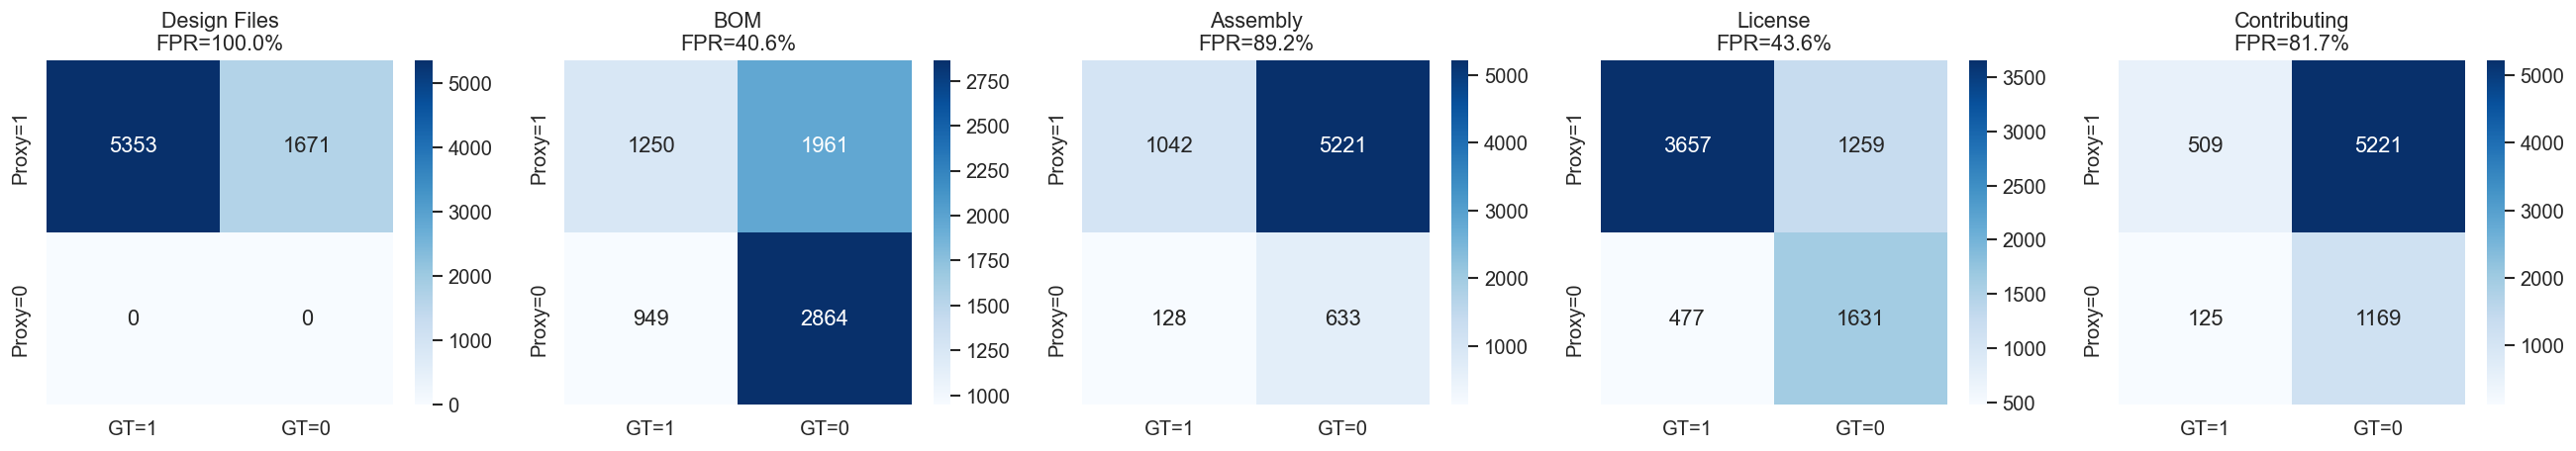

In [27]:
# Visual: confusion matrices side by side
fig, axes = plt.subplots(1, 5, figsize=(22, 4))
labels_list = [
    "Design Files", "BOM", "Assembly", "License", "Contributing"
]
cms = [cm_design, cm_bom, cm_assembly, cm_license, cm_contrib]

for ax, cm, label in zip(axes, cms, labels_list):
    matrix = np.array([[cm["tp"], cm["fp"]], [cm["fn"], cm["tn"]]])
    sns.heatmap(
        matrix, annot=True, fmt="d", cmap="Blues",
        xticklabels=["GT=1", "GT=0"],
        yticklabels=["Proxy=1", "Proxy=0"],
        ax=ax,
    )
    fpr = cm["fp"] / (cm["fp"] + cm["tn"]) if (cm["fp"] + cm["tn"]) > 0 else 0
    ax.set_title(f"{label}\nFPR={fpr:.1%}")

plt.tight_layout()
plt.show()

## 5. Score Relationships

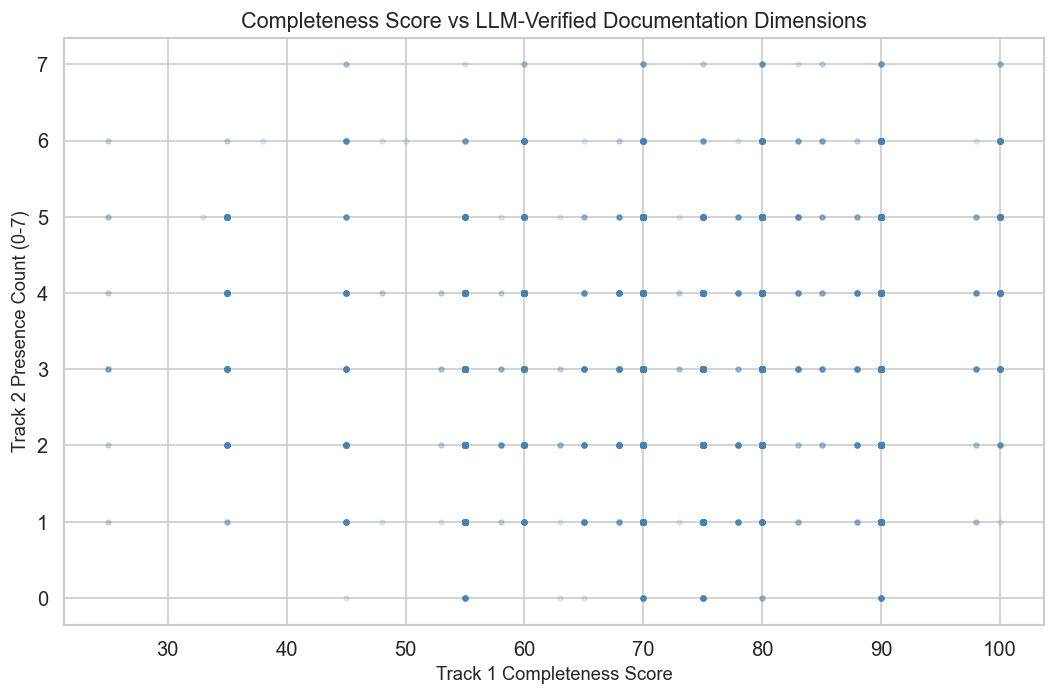

In [28]:
# Completeness vs count of Track 2 presence flags
t2_presence_cols = [
    "gt_assembly", "gt_hw_design", "gt_mech_design",
    "gt_bom", "gt_license", "gt_contributing", "gt_sw_fw",
]
df_scatter = df_xval.with_columns(
    sum(pl.col(c).cast(pl.Int32) for c in t2_presence_cols)
    .alias("t2_presence_count")
)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(
    df_scatter["completeness_score"].to_list(),
    df_scatter["t2_presence_count"].to_list(),
    alpha=0.15, s=8, color="steelblue",
)
ax.set_xlabel("Track 1 Completeness Score")
ax.set_ylabel("Track 2 Presence Count (0-7)")
ax.set_title("Completeness Score vs LLM-Verified Documentation Dimensions")
plt.tight_layout()
plt.show()

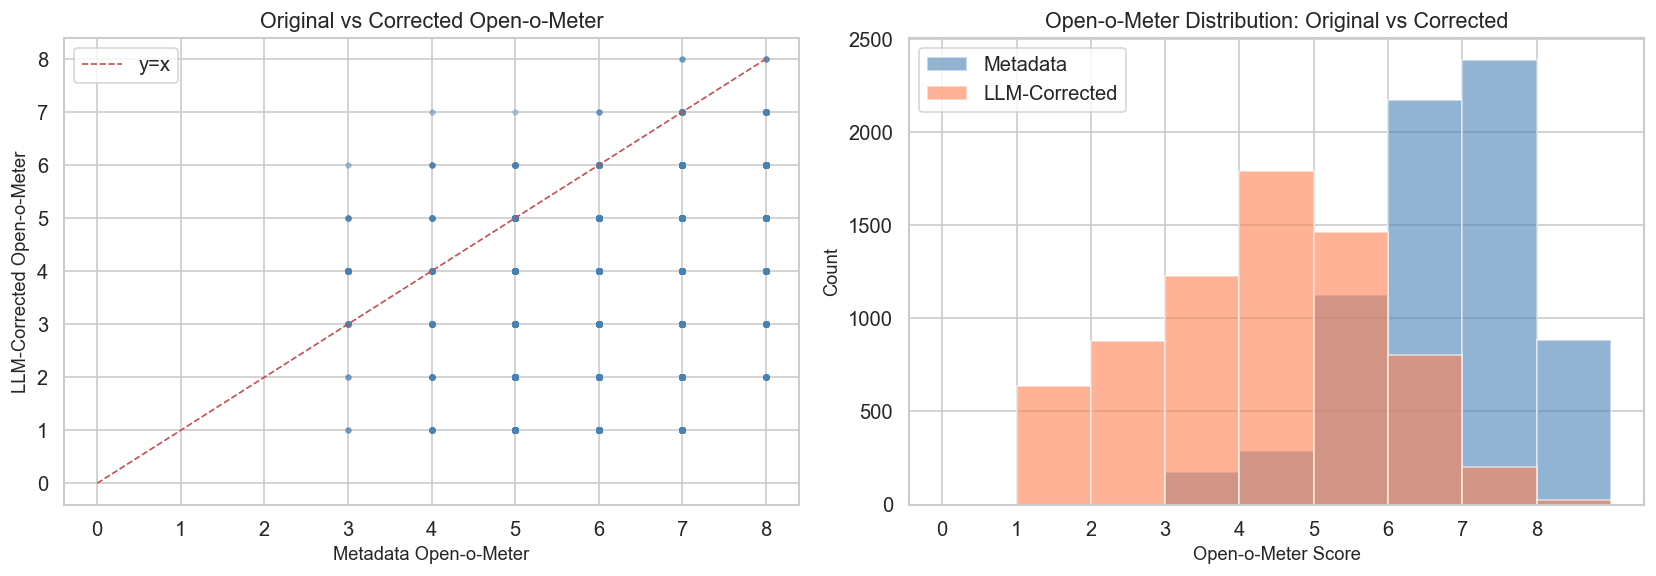

Mean metadata OoM: 6.28
Mean corrected OoM: 3.84
Mean shift: -2.44


In [29]:
# Corrected Open-o-Meter: replace proxy signals with LLM ground truth
# OoM dims: 1=design files, 2=BOM, 3=assembly, 4=editable format,
#           5=license, 6=VCS, 7=contributing, 8=issues
# We can correct dims 1-5 and 7 with Track 2 data.
# Dims 6 (VCS) and 8 (issues) remain from metadata (no LLM equivalent).

df_corrected = df_xval.with_columns([
    # dim 1: design files published (hw OR mech design)
    ((pl.col("gt_hw_design") == 1) | (pl.col("gt_mech_design") == 1))
    .cast(pl.Int32).alias("oom_dim1_corrected"),
    # dim 2: BOM published
    (pl.col("gt_bom") == 1).cast(pl.Int32).alias("oom_dim2_corrected"),
    # dim 3: assembly instructions
    (pl.col("gt_assembly") == 1).cast(pl.Int32).alias("oom_dim3_corrected"),
    # dim 4: editable source format
    (pl.col("gt_hw_editable") == 1).cast(pl.Int32).alias("oom_dim4_corrected"),
    # dim 5: open license
    (pl.col("gt_license") == 1).cast(pl.Int32).alias("oom_dim5_corrected"),
    # dim 7: contribution guide
    (pl.col("gt_contributing") == 1).cast(pl.Int32).alias("oom_dim7_corrected"),
])

# Dims 6 and 8 from metadata
df_corrected_full = sql("""
SELECT
    p.id AS project_id,
    (p.repo_url LIKE '%github.com%'
     OR p.repo_url LIKE '%gitlab.com%') AS oom_dim6_vcs,
    (rm.total_issues IS NOT NULL AND rm.total_issues > 0) AS oom_dim8_issues
FROM projects p
LEFT JOIN (
    SELECT project_id, MAX(total_issues) AS total_issues
    FROM repo_metrics GROUP BY project_id
) rm ON p.id = rm.project_id
WHERE p.id IN (
    SELECT project_id FROM llm_evaluations
)
""")

df_oom = df_corrected.join(
    df_corrected_full, on="project_id", how="left"
)

corrected_dims = [
    "oom_dim1_corrected", "oom_dim2_corrected", "oom_dim3_corrected",
    "oom_dim4_corrected", "oom_dim5_corrected", "oom_dim6_vcs",
    "oom_dim7_corrected", "oom_dim8_issues",
]
df_oom = df_oom.with_columns(
    sum(
        pl.col(c).cast(pl.Int32).fill_null(0) for c in corrected_dims
    ).alias("oom_corrected")
)

# Compare original vs corrected
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: original vs corrected
axes[0].scatter(
    df_oom["open_o_meter_score"].to_list(),
    df_oom["oom_corrected"].to_list(),
    alpha=0.1, s=8, color="steelblue",
)
axes[0].plot([0, 8], [0, 8], "r--", linewidth=1, label="y=x")
axes[0].set_xlabel("Metadata Open-o-Meter")
axes[0].set_ylabel("LLM-Corrected Open-o-Meter")
axes[0].set_title("Original vs Corrected Open-o-Meter")
axes[0].legend()

# Distribution comparison
oom_orig = df_oom["open_o_meter_score"].to_list()
oom_corr = df_oom["oom_corrected"].to_list()
axes[1].hist(oom_orig, bins=range(10), alpha=0.6, label="Metadata",
             color="steelblue", edgecolor="white")
axes[1].hist(oom_corr, bins=range(10), alpha=0.6, label="LLM-Corrected",
             color="coral", edgecolor="white")
axes[1].set_xlabel("Open-o-Meter Score")
axes[1].set_ylabel("Count")
axes[1].set_title("Open-o-Meter Distribution: Original vs Corrected")
axes[1].legend()
axes[1].set_xticks(range(9))

plt.tight_layout()
plt.show()

# Mean shift
print(f"Mean metadata OoM: {np.mean(oom_orig):.2f}")
print(f"Mean corrected OoM: {np.mean(oom_corr):.2f}")
print(f"Mean shift: {np.mean(oom_corr) - np.mean(oom_orig):+.2f}")

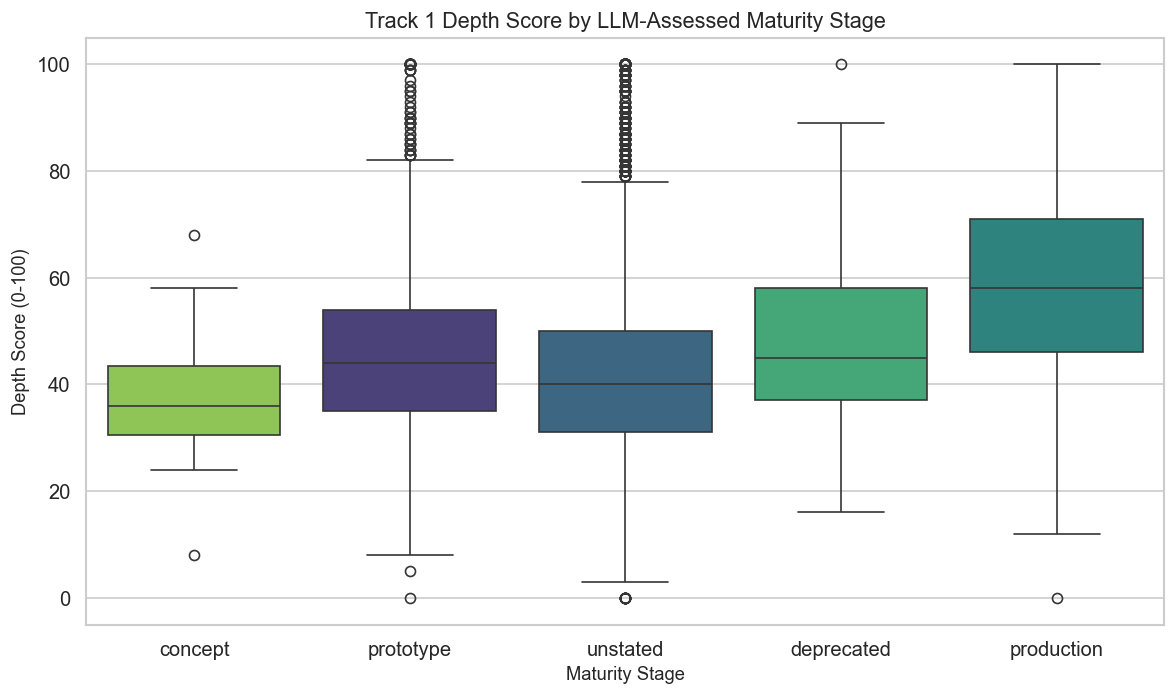

In [30]:
# Depth vs maturity stage
df_depth_mat = sql("""
SELECT
    d.depth_score,
    l.maturity_stage
FROM doc_quality_scores d
JOIN llm_evaluations l ON d.project_id = l.project_id
WHERE l.maturity_stage IS NOT NULL
""")

fig, ax = plt.subplots(figsize=(10, 6))
order = ["concept", "prototype", "unstated", "deprecated", "production"]
existing = [o for o in order if o in df_depth_mat["maturity_stage"].to_list()]
sns.boxplot(
    data=df_depth_mat.to_pandas(),
    x="maturity_stage", y="depth_score",
    order=existing, hue="maturity_stage",
    palette="viridis", legend=False, ax=ax,
)
ax.set_title("Track 1 Depth Score by LLM-Assessed Maturity Stage")
ax.set_xlabel("Maturity Stage")
ax.set_ylabel("Depth Score (0-100)")
plt.tight_layout()
plt.show()

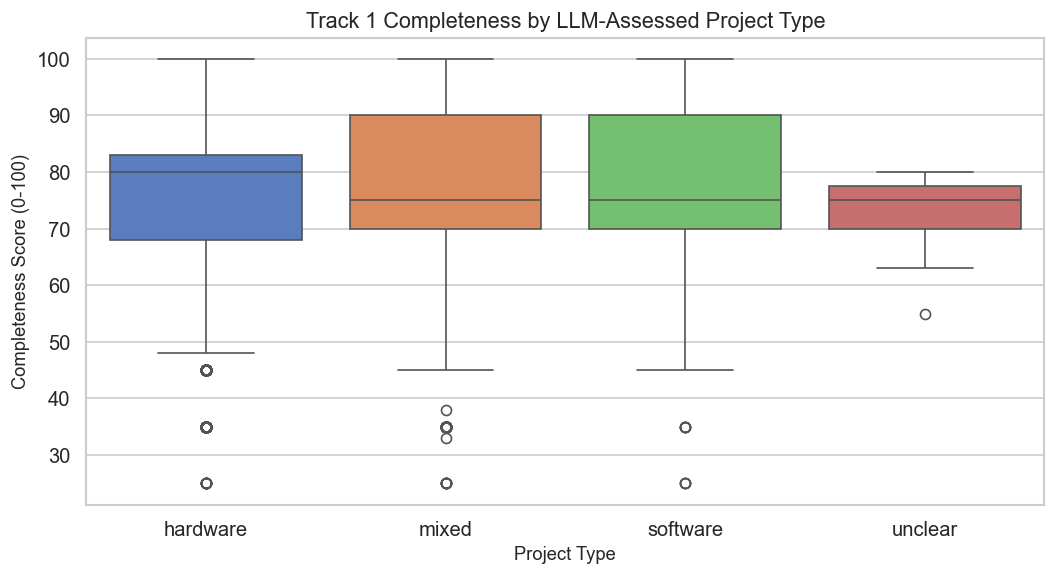

In [31]:
# Completeness vs project type
df_comp_type = sql("""
SELECT
    d.completeness_score,
    l.project_type
FROM doc_quality_scores d
JOIN llm_evaluations l ON d.project_id = l.project_id
WHERE l.project_type IS NOT NULL
""")

fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(
    data=df_comp_type.to_pandas(),
    x="project_type", y="completeness_score",
    hue="project_type", palette="muted", legend=False, ax=ax,
)
ax.set_title("Track 1 Completeness by LLM-Assessed Project Type")
ax.set_xlabel("Project Type")
ax.set_ylabel("Completeness Score (0-100)")
plt.tight_layout()
plt.show()

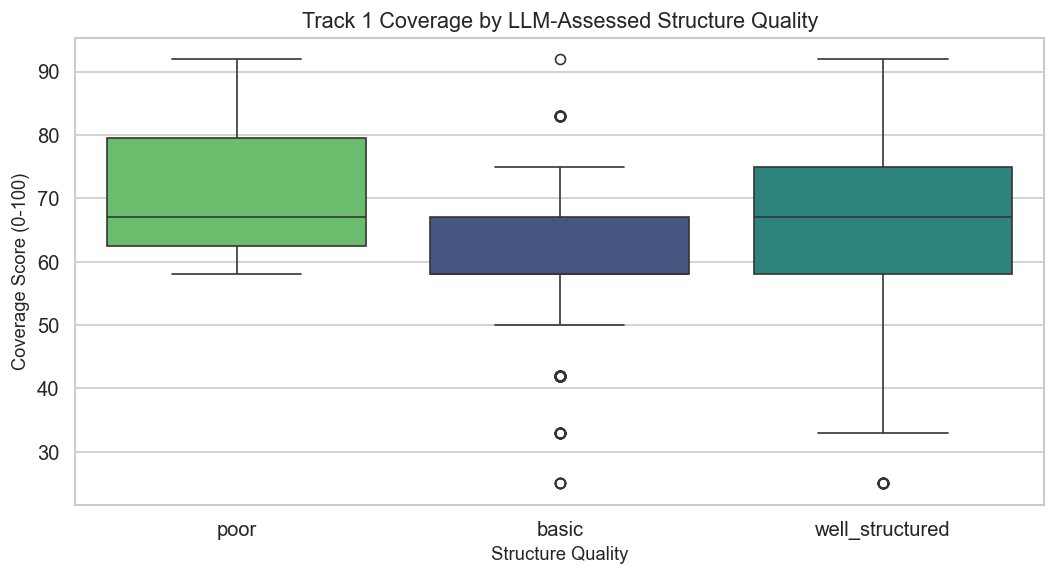

In [32]:
# Coverage vs structure quality
df_cov_struct = sql("""
SELECT
    d.coverage_score,
    l.structure_quality
FROM doc_quality_scores d
JOIN llm_evaluations l ON d.project_id = l.project_id
WHERE l.structure_quality IS NOT NULL
""")

fig, ax = plt.subplots(figsize=(9, 5))
order = ["poor", "basic", "well_structured"]
existing = [o for o in order if o in df_cov_struct["structure_quality"].to_list()]
sns.boxplot(
    data=df_cov_struct.to_pandas(),
    x="structure_quality", y="coverage_score",
    order=existing, hue="structure_quality",
    palette="viridis", legend=False, ax=ax,
)
ax.set_title("Track 1 Coverage by LLM-Assessed Structure Quality")
ax.set_xlabel("Structure Quality")
ax.set_ylabel("Coverage Score (0-100)")
plt.tight_layout()
plt.show()

## 6. Source-Level Analysis

shape: (10, 6)
┌────────────┬──────────────┬───────────┬───────────┬──────────────┬──────┐
│ source     ┆ completeness ┆ coverage  ┆ depth     ┆ open_o_meter ┆ n    │
│ ---        ┆ ---          ┆ ---       ┆ ---       ┆ ---          ┆ ---  │
│ str        ┆ f64          ┆ f64       ┆ f64       ┆ f64          ┆ u32  │
╞════════════╪══════════════╪═══════════╪═══════════╪══════════════╪══════╡
│ hackaday   ┆ 69.297876    ┆ 57.703879 ┆ 43.689135 ┆ 5.83974      ┆ 5697 │
│ oshwa      ┆ 67.052097    ┆ 66.559961 ┆ 64.925295 ┆ 4.855505     ┆ 3052 │
│ kitspace   ┆ 63.827957    ┆ 49.844086 ┆ 42.698925 ┆ 5.725806     ┆ 186  │
│ joh        ┆ 57.827586    ┆ 59.482759 ┆ 69.517241 ┆ 4.896552     ┆ 29   │
│ hardwareio ┆ 52.415534    ┆ 38.924272 ┆ 74.759223 ┆ 3.860194     ┆ 515  │
│ plos       ┆ 44.631579    ┆ 48.105263 ┆ 29.842105 ┆ 4.526316     ┆ 19   │
│ mendeley   ┆ 35.0         ┆ 42.0      ┆ 65.162921 ┆ 1.0          ┆ 178  │
│ ohx        ┆ 33.84127     ┆ 33.636684 ┆ 82.961199 ┆ 2.64903      ┆ 567 

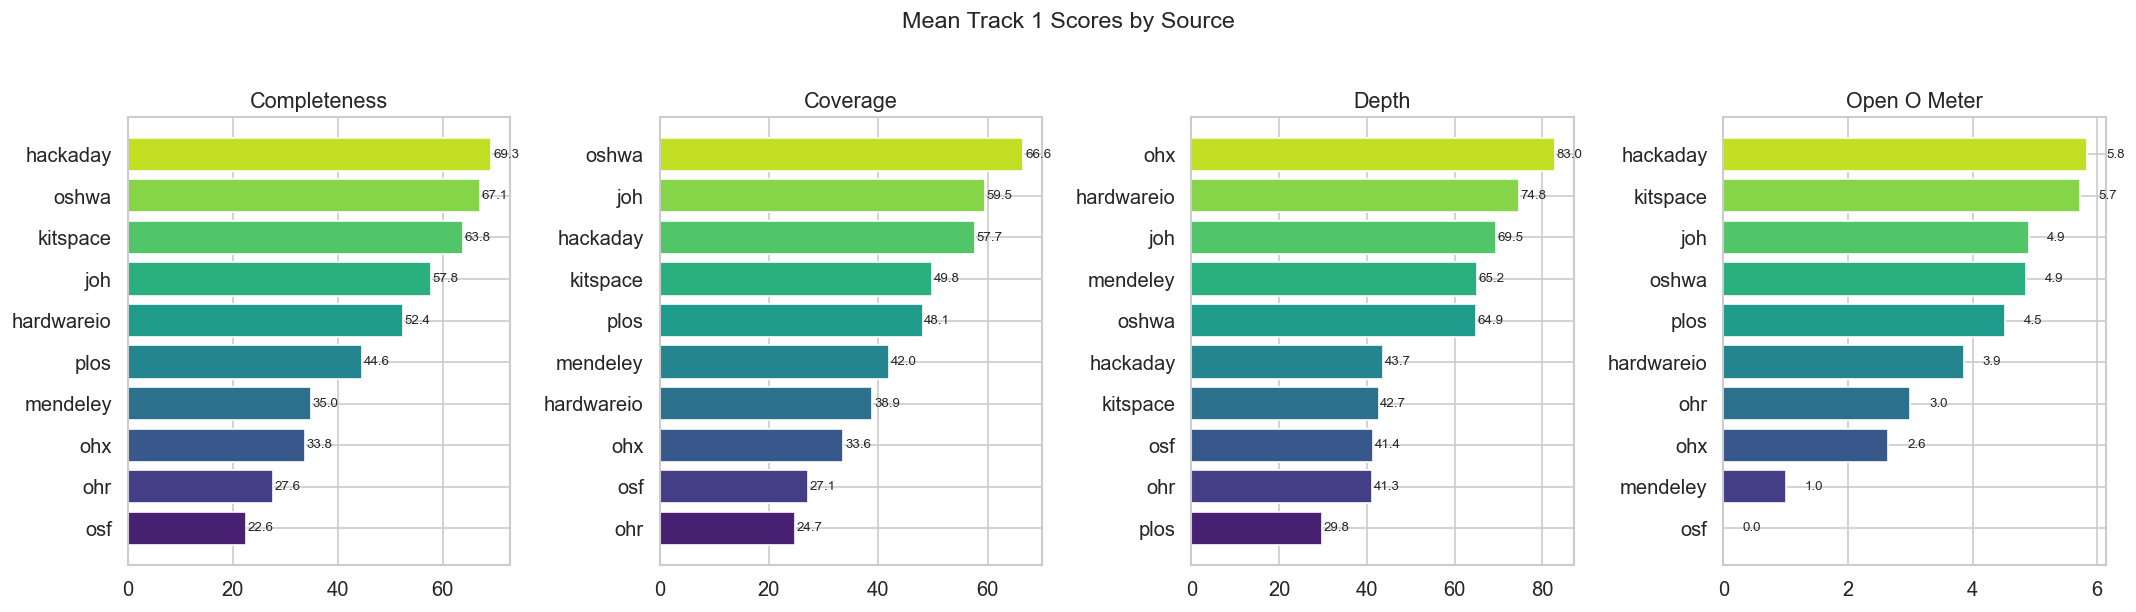

In [33]:
# Mean scores by source
score_by_source = (
    df_t1.group_by("source")
    .agg([
        pl.col("completeness_score").mean().alias("completeness"),
        pl.col("coverage_score").mean().alias("coverage"),
        pl.col("depth_score").mean().alias("depth"),
        pl.col("open_o_meter_score").mean().alias("open_o_meter"),
        pl.len().alias("n"),
    ])
    .sort("completeness", descending=True)
)
print(score_by_source)

# Bar chart
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, metric in zip(
    axes, ["completeness", "coverage", "depth", "open_o_meter"]
):
    sorted_df = score_by_source.sort(metric, descending=True)
    sources = sorted_df["source"].to_list()
    vals = sorted_df[metric].to_list()
    ax.barh(sources[::-1], vals[::-1],
            color=sns.color_palette("viridis", len(sources)))
    ax.set_title(metric.replace("_", " ").title())
    for i, v in enumerate(vals[::-1]):
        ax.text(v + 0.3, i, f"{v:.1f}", va="center", fontsize=8)

fig.suptitle("Mean Track 1 Scores by Source", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

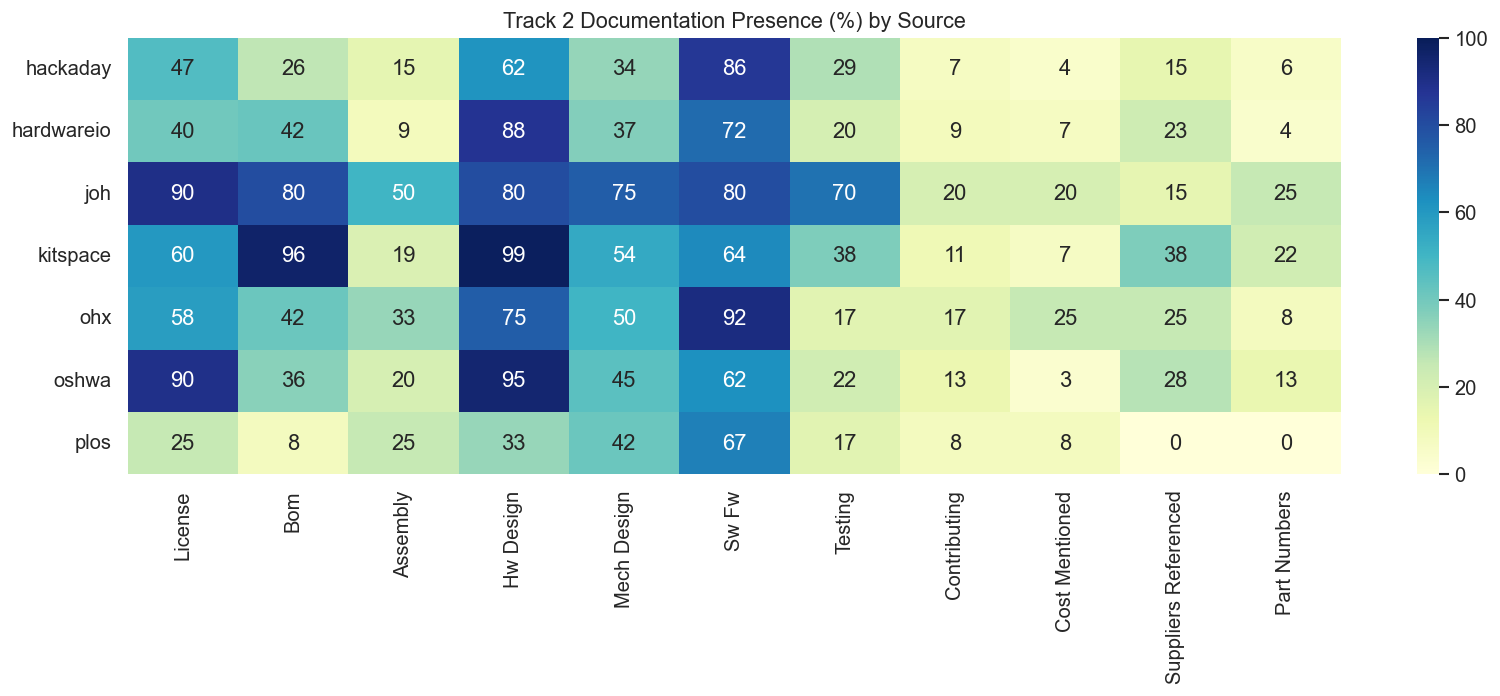

In [34]:
# Track 2 presence rates by source (heatmap)
t2_binary_cols = [
    "license_present", "bom_present", "assembly_present",
    "hw_design_present", "mech_design_present",
    "sw_fw_present", "testing_present", "contributing_present",
    "cost_mentioned", "suppliers_referenced", "part_numbers_present",
]

t2_by_source = (
    df_t2.group_by("source")
    .agg([
        (pl.col(c).cast(pl.Int32).sum() / pl.len() * 100).alias(c)
        for c in t2_binary_cols
    ] + [pl.len().alias("n")])
    .sort("source")
)

# Only plot sources with enough Track 2 data
t2_by_source_filtered = t2_by_source.filter(pl.col("n") >= 10)
matrix = t2_by_source_filtered.select(t2_binary_cols).to_pandas()
matrix.index = t2_by_source_filtered["source"].to_list()
matrix.columns = [
    c.replace("_present", "").replace("_", " ").title()
    for c in t2_binary_cols
]

fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(
    matrix, annot=True, fmt=".0f", cmap="YlGnBu",
    ax=ax, vmin=0, vmax=100,
)
ax.set_title("Track 2 Documentation Presence (%) by Source")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

In [35]:
# Top 10 and bottom 10 projects by completeness
df_ranked = sql("""
SELECT
    p.name,
    p.source,
    d.completeness_score,
    d.coverage_score,
    d.depth_score,
    d.open_o_meter_score
FROM doc_quality_scores d
JOIN projects p ON d.project_id = p.id
ORDER BY d.completeness_score DESC, d.depth_score DESC
""")

print("Top 10 by Completeness:")
print(df_ranked.head(10))
print("\nBottom 10 by Completeness:")
print(df_ranked.tail(10))

Top 10 by Completeness:
shape: (10, 6)
┌───────────────────┬────────┬───────────────────┬────────────────┬─────────────┬──────────────────┐
│ name              ┆ source ┆ completeness_scor ┆ coverage_score ┆ depth_score ┆ open_o_meter_sco │
│ ---               ┆ ---    ┆ e                 ┆ ---            ┆ ---         ┆ re               │
│ str               ┆ str    ┆ ---               ┆ i64            ┆ i64         ┆ ---              │
│                   ┆        ┆ i64               ┆                ┆             ┆ i64              │
╞═══════════════════╪════════╪═══════════════════╪════════════════╪═════════════╪══════════════════╡
│ MagSpoof          ┆ oshwa  ┆ 100               ┆ 83             ┆ 97          ┆ 6                │
│ Moonrat Portable  ┆ oshwa  ┆ 100               ┆ 92             ┆ 92          ┆ 8                │
│ Incubator         ┆        ┆                   ┆                ┆             ┆                  │
│ BlueRetro         ┆ oshwa  ┆ 100               ┆ 9

In [36]:
# Platform-specific documentation gaps
# For each source in Track 2, which dimensions are most commonly missing?
sources_in_t2 = t2_by_source_filtered["source"].to_list()

print("Documentation gaps by source (dimensions with <30% presence):\n")
for source in sorted(sources_in_t2):
    row = t2_by_source_filtered.filter(pl.col("source") == source)
    n = row["n"][0]
    gaps = []
    for col in t2_binary_cols:
        rate = row[col][0]
        if rate < 30:
            label = col.replace("_present", "").replace("_", " ")
            gaps.append(f"{label} ({rate:.0f}%)")
    if gaps:
        print(f"  {source} (n={n}): {', '.join(gaps)}")
    else:
        print(f"  {source} (n={n}): No major gaps")

Documentation gaps by source (dimensions with <30% presence):

  hackaday (n=4646): bom (26%), assembly (15%), testing (29%), contributing (7%), cost mentioned (4%), suppliers referenced (15%), part numbers (6%)
  hardwareio (n=216): assembly (9%), testing (20%), contributing (9%), cost mentioned (7%), suppliers referenced (23%), part numbers (4%)
  joh (n=20): contributing (20%), cost mentioned (20%), suppliers referenced (15%), part numbers (25%)
  kitspace (n=160): assembly (19%), contributing (11%), cost mentioned (7%), part numbers (22%)
  ohx (n=12): testing (17%), contributing (17%), cost mentioned (25%), suppliers referenced (25%), part numbers (8%)
  oshwa (n=1958): assembly (20%), testing (22%), contributing (13%), cost mentioned (3%), suppliers referenced (28%), part numbers (13%)
  plos (n=12): license (25%), bom (8%), assembly (25%), testing (17%), contributing (8%), cost mentioned (8%), suppliers referenced (0%), part numbers (0%)


## 7. Key Findings

In [37]:
# Compute summary statistics for the findings narrative
n_projects = len(df_t1)
n_t2 = len(df_t2)
mean_completeness = df_t1["completeness_score"].mean()
mean_coverage = df_t1["coverage_score"].mean()
mean_depth = df_t1["depth_score"].mean()
mean_oom = df_t1["open_o_meter_score"].mean()

# Use overlap subset for fair OoM comparison
mean_oom_overlap = np.mean(df_oom["open_o_meter_score"].to_list())
mean_oom_corrected = np.mean(oom_corr)

# Hardware vs software in Track 2
n_hardware = df_t2.filter(pl.col("project_type") == "hardware").height
n_software = df_t2.filter(pl.col("project_type") == "software").height
n_mixed = df_t2.filter(pl.col("project_type") == "mixed").height

print("=" * 60)
print("KEY FINDINGS SUMMARY")
print("=" * 60)
print(f"\nDataset: {n_projects:,} projects, {n_t2:,} with LLM evaluation")
print(f"\nTrack 1 Mean Scores (all {n_projects:,} projects):")
print(f"  Completeness: {mean_completeness:.1f}/100")
print(f"  Coverage:     {mean_coverage:.1f}/100")
print(f"  Depth:        {mean_depth:.1f}/100")
print(f"  Open-o-Meter: {mean_oom:.2f}/8")
print(f"\nOpen-o-Meter Inflation ({n_t2:,} overlap projects):")
print(f"  Metadata OoM:      {mean_oom_overlap:.2f}/8")
print(f"  LLM-Corrected OoM: {mean_oom_corrected:.2f}/8")
print(f"  Overestimate:       {mean_oom_overlap - mean_oom_corrected:+.2f} points")
print(f"\nTrack 2 Project Types:")
print(f"  Hardware: {n_hardware} ({n_hardware/n_t2*100:.1f}%)")
print(f"  Mixed:    {n_mixed} ({n_mixed/n_t2*100:.1f}%)")
print(f"  Software: {n_software} ({n_software/n_t2*100:.1f}%)")
print(f"\nProxy False-Positive Rates:")
print(f"  README -> Assembly: {fpr_assembly:.1%}")
print(f"  Repo URL -> Design: {fpr_design:.1%}")
print(f"  BOM metadata -> BOM: {fpr_bom:.1%}")
print(f"  License metadata -> License: {fpr_license:.1%}")
print(f"  Community health -> Contributing: {fpr_contrib:.1%}")

KEY FINDINGS SUMMARY

Dataset: 10,698 projects, 7,024 with LLM evaluation

Track 1 Mean Scores (all 10,698 projects):
  Completeness: 63.4/100
  Coverage:     56.3/100
  Depth:        53.6/100
  Open-o-Meter: 5.03/8

Open-o-Meter Inflation (7,024 overlap projects):
  Metadata OoM:      6.28/8
  LLM-Corrected OoM: 3.84/8
  Overestimate:       +2.44 points

Track 2 Project Types:
  Hardware: 4100 (58.4%)
  Mixed:    2404 (34.2%)
  Software: 509 (7.2%)

Proxy False-Positive Rates:
  README -> Assembly: 89.2%
  Repo URL -> Design: 100.0%
  BOM metadata -> BOM: 40.6%
  License metadata -> License: 43.6%
  Community health -> Contributing: 81.7%


### 7.1 The Open-o-Meter Inflation Problem

The most consequential finding is that the metadata-based Open-o-Meter systematically
inflates openness scores. The mean metadata OoM for the 7,024 overlap projects is 6.28/8;
the LLM-corrected version drops to 3.84/8 -- a **2.44-point overestimate**, or roughly
30% of the scale. This is not a small calibration error; it changes the qualitative
interpretation from "most projects are reasonably open" to "most projects have significant
documentation gaps."

The inflation traces to two specific dimensions:

**Dimension 3 (assembly instructions):** The proxy assumes that having a README or
documentation URL implies assembly instructions exist. In reality, of the 6,263 projects
where `has_readme=1`, only 1,042 (16.6%) actually contain assembly instructions according
to the LLM. The remaining 5,221 are false positives -- an 89.2% FPR. Even among the
projects the LLM identifies as having assembly content, 624 are merely "referenced" (a
link to external docs) and only 179 have "detailed" step-by-step instructions. Assembly
documentation is the single rarest substantive artifact in OSH: just 16.7% of Track 2
projects have it at all.

**Dimension 7 (contribution guide):** The proxy uses `community_health >= 25` from GitHub's
Community Profile API. Of 5,730 projects above this threshold, only 509 (8.9%) actually
have a contributing guide per the LLM -- an 81.7% FPR. The community health percentage
captures a mix of signals (README, license, code of conduct, issue templates) that are
largely unrelated to whether a CONTRIBUTING.md exists. Among the 5,730 proxy-positive
projects, 5,180 (90.4%) have contributing_level=0, meaning no contribution guidance
whatsoever.

These two dimensions alone account for ~2 of the 2.44-point shift. The implication is
stark: the original Bonvoisin & Mies (2018) Open-o-Meter, when operationalized with
metadata proxies, produces scores that are unreliable for comparing projects or drawing
conclusions about the state of OSH documentation.

### 7.2 What OSH Projects Actually Document (and Don't)

Track 2 reveals a clear hierarchy of documentation investment across 7,024 GitHub-hosted
projects:

| Tier | Dimension | Presence |
|------|-----------|----------|
| Common | Software/firmware | 78.8% |
| Common | Hardware design files | 72.5% |
| Common | License | 58.9% |
| Moderate | Mechanical design | 37.6% |
| Moderate | BOM | 31.3% |
| Moderate | Testing | 27.1% |
| Rare | Suppliers referenced | 19.2% |
| Rare | Assembly instructions | 16.7% |
| Rare | Contributing guide | 9.0% |
| Rare | Part numbers | 8.1% |
| Rare | Cost information | 4.3% |

The pattern tells a story about what OSH creators prioritize: they publish code and design
files (the artifacts they produce while building), add a license when prompted by GitHub,
but rarely invest in the downstream documentation that would enable someone else to
actually *reproduce* the hardware. Assembly instructions, supplier sourcing information,
and cost breakdowns -- the artifacts that distinguish a published design from a reproducible
one -- are present in fewer than 1-in-5 projects.

BOM quality is particularly shallow. Of the 2,199 projects with any BOM present, 1,801
(81.9%) are "partial" -- missing key columns like quantities, manufacturers, or part
numbers. Only 72 projects (3.3% of BOM-having projects) have a "complete" BOM with
manufacturers, part numbers, and quantities. This explains the 0.52% pricing coverage:
without structured part numbers, automated price lookup is impossible.

### 7.3 The Project Type Contamination Problem

The LLM classified 509 of 7,024 projects (7.2%) as purely "software" and 2,404 (34.2%)
as "mixed" (hardware + significant software). Only 4,100 (58.4%) are cleanly "hardware."
This matters because metadata proxies cannot distinguish project types -- a software repo
with a README, license, and active issues scores 6/8 on the metadata OoM despite having
zero hardware documentation.

The 1,671 design-files false positives break down as: 780 mixed projects, 485 software
projects, and 395 hardware projects that have a repo but no actual design files in it.
The software projects inflate OoM dimensions 1 and 4 (design files published, editable
format) by their mere presence on GitHub.

### 7.4 Source-Level Documentation Profiles

The 10 data sources fall into distinct documentation archetypes:

**High completeness, high depth (OSHWA, n=3,052):** Mean completeness 67.1, coverage
66.6, depth 64.9. OSHWA certification requires structured metadata submission, which
guarantees license, description, and author fields. Track 2 confirms 89.6% license
presence and 94.6% hardware design files -- the highest rates of any large source. However,
only 13.1% have contributing guides and 3.2% mention costs.

**High completeness, low depth (Hackaday, n=5,697):** Mean completeness 69.3 (highest),
but depth only 43.7. Hackaday projects are well-connected to GitHub repos (driving OoM
5.84, the highest), but the repos themselves are shallow: only 26.5% have BOMs, 15.3%
have assembly instructions, and 5.6% list part numbers. The high completeness reflects
Hackaday.io's mandatory metadata fields, not substantive documentation.

**Low completeness, high depth (HardwareX, n=567):** Mean completeness 33.8, but depth
83.0 (highest of any source). HardwareX projects are published academic papers with
peer-reviewed methodology, explaining the high depth signal (long descriptions, structured
content). But they lack GitHub repos (OoM 2.65), so they miss the infrastructure signals
that drive completeness. Track 2 confirms 42.1% BOM and 33.3% assembly for the small
subset (n=12) on GitHub.

**Research-only (OSF, n=208, Mendeley, n=178):** The lowest completeness scores (22.6 and
35.0 respectively). These are dataset repositories and paper supplements, not project
pages. OSF projects have OoM=0.0 (no GitHub repos at all). They are arguably miscategorized
as "OSH projects" and may warrant a separate analysis category.

**Kitspace (n=186):** The BOM specialist. Track 2 shows 96.3% BOM presence and 98.8%
hardware design files -- unsurprising since Kitspace is specifically a PCB project
registry. Yet only 18.8% have assembly instructions and 6.9% mention costs, reinforcing
the pattern that design publication and reproducibility documentation are separate concerns.

### 7.5 The License Detection Gap

License detection shows the strongest agreement between tracks but with instructive
asymmetries. The metadata proxy (any row in the `licenses` table) has a 43.6% FPR: 1,259
projects have a metadata license entry but the LLM found no license in the README or file
tree. These are likely projects where the scraper captured a license from the source
platform's metadata (e.g., OSHWA self-declaration) but the actual repository lacks a
LICENSE file.

In the other direction, 477 projects have LLM-detected licenses that metadata missed.
Of these, 272 are "explicit" (license text in README), 140 are "file reference" (LICENSE
file exists but not captured by scrapers), and 26 are "referenced" (mentioned by name
without full text). This suggests the metadata pipeline should parse README content for
license declarations.

Only 1,006 projects have a hardware-specific license name identified by the LLM, 1,095
have a software license name, and 1,010 have a documentation license. The near-equal
numbers suggest that the small fraction of projects that do license properly tend to apply
domain-specific licenses across all three artifact types.

### 7.6 Maturity and Depth

The depth score monotonically increases with LLM-assessed maturity: concept (37.7),
prototype (46.3), unstated (42.7), production (59.5). This validates depth as a proxy for
project investment -- more mature projects accumulate more contributors, releases, and
community health. However, the "deprecated" category scores 49.0, above prototype, because
deprecated projects had a full development lifecycle before being archived.

The 4,628 projects (65.9%) classified as "unstated" maturity -- where the LLM could not
determine maturity from the README -- represent a major analysis gap. These projects lack
the contextual cues (version numbers, roadmaps, status badges) that would enable maturity
classification.

### 7.7 Next Steps

1. **Weighted/corrected scoring:** Use the per-proxy FPR estimates from Section 4 to produce
   a *calibrated* completeness score that discounts signals proportional to their false-positive
   rates. For the 7,024 overlap projects, compare calibrated Track 1 scores against Track 2
   to quantify the improvement.

2. **Source-stratified analysis:** The Hackaday-dominance problem (53% of all projects) means
   aggregate statistics are essentially Hackaday statistics. All cross-validation rates should
   be recomputed per-source to determine whether proxy reliability varies by platform.

3. **BOM-to-pricing pipeline:** The 72 projects with "complete" BOMs (per LLM) are prime
   candidates for pricing enrichment. Cross-reference these with the BOM normalization columns
   (component_category, manufacturer_canonical, footprint_normalized) to assess how many have
   structured enough data for automated price lookup.

4. **Maturity prediction:** The 4,628 "unstated" maturity projects may be classifiable using
   Track 1 depth signals (releases_count, years_since_update, contributor_count) as features.
   A simple decision tree trained on the 2,396 projects with known maturity could label the rest.

5. **Software project filtering:** The 509 software-only projects should be flagged or excluded
   from hardware documentation quality analysis. The `project_type` field from Track 2 can
   serve as ground truth for training a classifier on metadata features (primary_language,
   has_bom, topics) to extend the filter to the remaining 3,674 non-Track-2 projects.

6. **README license extraction:** The 477 projects where the LLM found licenses that metadata
   missed represent recoverable data. A targeted regex pass over `readme_contents` could
   backfill the `licenses` table and improve completeness scores without re-running the LLM.